# Marvel exercises: weeks 1-3, and the dataset-free parts of week 4

02805 Social Graphs and Interactions.

The Marvel network: 303 Wikipedia articles for Marvel characters (`data/week1_nodes.tsv`), with a
directed arc A -> B when A's article links to B's (`data/week1_edges.tsv`, 1,784 arcs). Frozen
snapshot, so every group computes on identical data. No weights, no attributes beyond names.

This notebook is the home for every tool exercise from weeks 1-3 that needs the Marvel network, plus
the sub-parts of week 4 that run on it instead of the philosophers (community detection needs no
philosophy-specific data). `02_marvel_degrees.ipynb` already does exercise 1.6 in full depth; this
notebook covers it compactly and links back.

## What this notebook covers

| Exercise | Covered |
|---|---|
| 1.6 | compact version (full version in `02_marvel_degrees.ipynb`) |
| 2.2, 2.4, 2.5b, 2.6, 2.8, 2.9 | full |
| 3.3, 3.5, 3.7, 3.8, 3.9 | full |
| Cliques (Part 8, week 3) | full |
| 4.5, 4.6, 4.9 | full, run on the Marvel giant component in place of the philosophers |

**Skipped, paper-only 🧠 exercises** (pen and paper by design, not notebook work): 1.5, 1.7, 2.3,
2.7, 3.2, 3.4, 3.6, 3.10, 4.1, 4.2, 4.3, 4.7, 4.8, 4.10.

**Skipped, 🚀 Builder items** (not notebook work): 1.3, 1.8, 2.10, 2.11, 3.11, 3.12, 4.4, 4.12, 4.13.

**Skipped LLM-grading sub-items** inside tool exercises: 2.6's "ask your favorite LLM", 2.9 item 4,
3.5 item 4, 3.7's LLM check. We never write or invent an LLM transcript.

**Skipped, dataset cannot support it:**
- 3.9's homophily sub-item: needs a live Wikipedia/Wikidata fetch of team membership (X-Men,
  Avengers, ...). The `description` column is free text, not a clean categorical label, and this
  notebook stays offline. Homophily by attribute runs in `04_migration_exercises.ipynb`, where region
  is a real categorical attribute.
- 4.9's Wikipedia-reading validation of overlap/disagreement: same reason, offline.
- 4.11 (disparity filter / backbone): Marvel is unweighted. A backbone needs a weight to filter on;
  the closest thing here, reciprocity (a link is weight 1 or 2, mutual or not), carries no information
  a disparity filter can use. 4.11 runs on real weights in `04_migration_exercises.ipynb` and
  `05_h1b_exercises.ipynb`.

## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore", module="powerlaw")  # its warnings print local install paths
import sys
import time
import random

import numpy as np
import pandas as pd
import networkx as nx
import networkx.algorithms.community as nc
import igraph as ig
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import normalized_mutual_info_score as nmi

sys.path.insert(0, "../analysis")
from week04_staffing import tracked, span, to_igraph, louvain as igraph_louvain

# validated for colour-blind separation on all pairs (see notebook 01)
BLUE, ORANGE, GREEN = "#2a78d6", "#eb6834", "#1baf7a"
PURPLE, RED = "#8659c9", "#d6425b"
INK, MUTED, GRID = "#2B2B2B", "#6B6B6B", "#DDDDDD"
PALETTE = [BLUE, ORANGE, GREEN, PURPLE, RED, "#c9a02a", "#4aa8a0", "#a85b8f"]

DATA = "../data"
SEED = 2805
rng = np.random.default_rng(SEED)

def style(ax, xlabel, ylabel):
    ax.set_xlabel(xlabel, fontsize=9, color=MUTED)
    ax.set_ylabel(ylabel, fontsize=9, color=MUTED)
    ax.tick_params(labelsize=8, colors=MUTED, length=0)
    ax.grid(True, color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)
    for s in ax.spines.values():
        s.set_visible(False)

t0 = time.time()

## 1.6: The distribution, compact version

Load the network keeping the isolates, check the basic counts, and look at the in/out-degree
distributions with the course's doubling-bin scheme. `02_marvel_degrees.ipynb` does this exercise in
full (specimens, binning proof, the power-law-or-not discussion); this section is the numbers this
notebook needs going forward.

In [2]:
nodes = pd.read_csv(f"{DATA}/week1_nodes.tsv", sep="\t", comment="#")
edges = pd.read_csv(f"{DATA}/week1_edges.tsv", sep="\t", comment="#", names=["source", "target"])

D = nx.DiGraph()
D.add_nodes_from(nodes.node_id)          # isolates survive because of this line
D.add_edges_from(edges.itertuples(index=False, name=None))
name = dict(zip(nodes.node_id, nodes.name))
N = D.number_of_nodes()
U = D.to_undirected()
m = U.number_of_edges()
mean_k = 2 * m / N

print(f"nodes                 {N}")
print(f"directed arcs         {D.number_of_edges()}")
print(f"undirected edges m    {m}")
print(f"mean degree <k>       {mean_k:.3f}")

assert N == 303
assert D.number_of_edges() == 1784
assert m == 1434
assert round(mean_k, 1) == 9.5

nodes                 303
directed arcs         1784
undirected edges m    1434
mean degree <k>       9.465


In [3]:
def raw_pk(degrees, n):
    u, counts = np.unique(np.asarray(degrees) + 1, return_counts=True)
    return u, counts / n

def bin_edges(umax):
    e = list(range(1, 9))
    hi = 8
    while hi <= umax:
        e.append(hi * 2)
        hi *= 2
    return np.array(e)

def binned_pk(degrees, n):
    u = np.asarray(degrees) + 1
    e = bin_edges(u.max())
    counts, _ = np.histogram(u, bins=e)
    widths = np.diff(e)
    density = counts / (widths * n)
    centres = np.array([np.exp(np.mean(np.log(np.arange(lo, hi)))) for lo, hi in zip(e[:-1], e[1:])])
    keep = counts > 0
    return centres[keep], density[keep]

k_in = [d for _, d in D.in_degree()]
k_out = [d for _, d in D.out_degree()]

def leaderboard(degree_view, n=5):
    return [(name[node], d) for node, d in sorted(degree_view, key=lambda kv: -kv[1])[:n]]

print("TOP 5 IN-DEGREE"); [print(f"  {i}. {nm} - {d}") for i, (nm, d) in enumerate(leaderboard(D.in_degree()), 1)]
print("TOP 5 OUT-DEGREE"); [print(f"  {i}. {nm} - {d}") for i, (nm, d) in enumerate(leaderboard(D.out_degree()), 1)]

assert leaderboard(D.in_degree())[0] == ("Spider-Man", 106)
assert max(k_out) == 28 and name[max(D.out_degree(), key=lambda kv: kv[1])[0]] == "Betsy Braddock"
print()
print(f"in-degree max {max(k_in)} (brief: Spider-Man 106)   out-degree max {max(k_out)} (brief: Betsy Braddock 28)")

TOP 5 IN-DEGREE
  1. Spider-Man - 106
  2. Hulk - 64
  3. Wolverine (character) - 60
  4. Doctor Strange - 50
  5. Deadpool - 33
TOP 5 OUT-DEGREE
  1. Betsy Braddock - 28
  2. Cloak and Dagger (characters) - 24
  3. Adam Warlock - 22
  4. Venom (character) - 21
  5. She-Hulk - 20

in-degree max 106 (brief: Spider-Man 106)   out-degree max 28 (brief: Betsy Braddock 28)


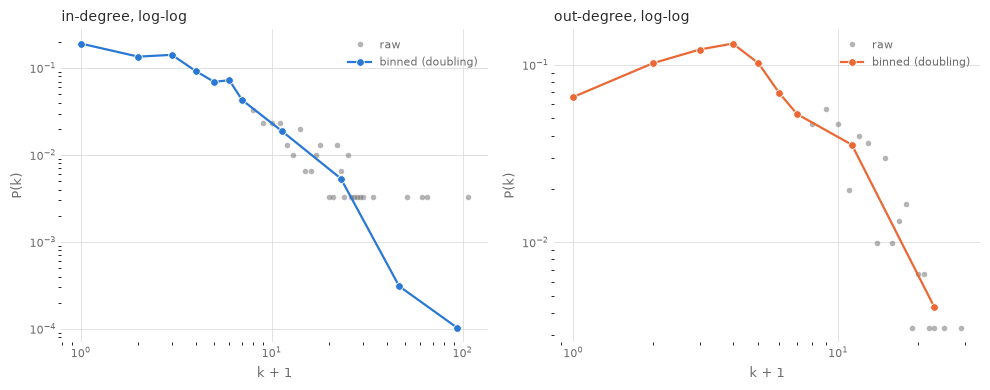

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (label, ks, colour) in zip(axes, [("in", k_in, BLUE), ("out", k_out, ORANGE)]):
    ru, rp = raw_pk(ks, N)
    bu, bp = binned_pk(ks, N)
    ax.plot(ru, rp, "o", color=MUTED, markersize=4, alpha=0.5, markeredgecolor="none", label="raw")
    ax.plot(bu, bp, "-o", color=colour, markersize=5.5, linewidth=1.6,
            markeredgecolor="white", markeredgewidth=0.6, label="binned (doubling)")
    ax.set_xscale("log"); ax.set_yscale("log")
    style(ax, "k + 1", "P(k)")
    ax.set_title(f"{label}-degree, log-log", fontsize=10, color=INK, loc="left")
    ax.legend(frameon=False, fontsize=8, labelcolor=MUTED)
fig.tight_layout(); plt.show()

Top five and both extremes match the explorable (Spider-Man in-degree 106, Betsy Braddock out-degree
28). Full derivation, the binning proof, and the power-law discussion live in `02_marvel_degrees.ipynb`.

## 2.2: The random network, as code

$G(n,p)$ at $n=5{,}000$, $\langle k\rangle=10$ against a Poisson overlay, then $\langle k\rangle=100$
against a normal overlay; the phase transition swept over $\langle k\rangle \in [0.2, 4]$; the
$n=200$, $\langle k\rangle=1.5$ two-step picture; and a same-$n,m$ random network next to Marvel in a
comparison table we keep growing through the notebook.

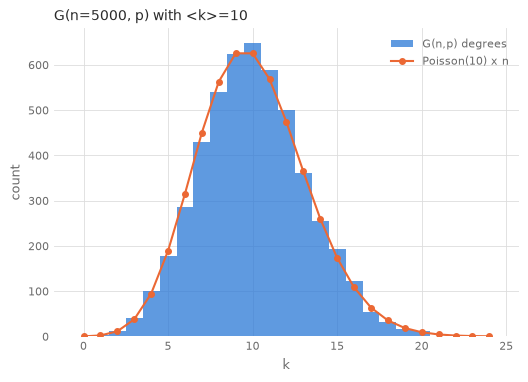

max degree observed 24   Poisson 1/n tail quantile ~ 23


In [5]:
n1, kbar1 = 5000, 10
p1 = kbar1 / (n1 - 1)
G1 = nx.gnp_random_graph(n1, p1, seed=SEED)
degs1 = np.array([d for _, d in G1.degree()])

fig, ax = plt.subplots(figsize=(6, 4))
kmax = degs1.max()
bins = np.arange(0, kmax + 2) - 0.5
ax.hist(degs1, bins=bins, color=BLUE, alpha=0.75, label="G(n,p) degrees")
ks = np.arange(0, kmax + 1)
ax.plot(ks, stats.poisson.pmf(ks, kbar1) * n1, "o-", color=ORANGE, markersize=4, label="Poisson(10) x n")
style(ax, "k", "count")
ax.set_title(f"G(n={n1}, p) with <k>={kbar1}", fontsize=10, color=INK, loc="left")
ax.legend(frameon=False, fontsize=8, labelcolor=MUTED)
plt.show()

max_k_predicted = stats.poisson.ppf(1 - 1 / n1, kbar1)
print(f"max degree observed {degs1.max()}   Poisson 1/n tail quantile ~ {max_k_predicted:.0f}")

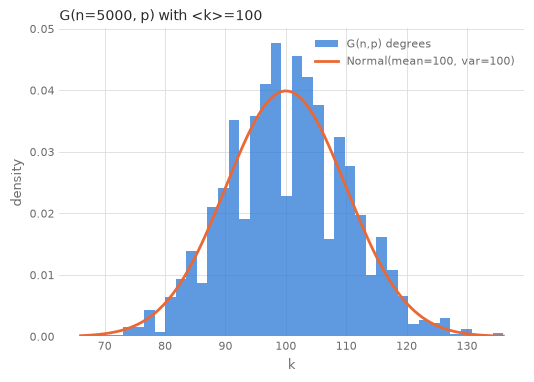

empirical mean 100.29  var 100.67   (target: mean 100, var 100)


In [6]:
n2, kbar2 = 5000, 100
p2 = kbar2 / (n2 - 1)
G2 = nx.gnp_random_graph(n2, p2, seed=SEED)
degs2 = np.array([d for _, d in G2.degree()])

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(degs2, bins=40, density=True, color=BLUE, alpha=0.75, label="G(n,p) degrees")
xs = np.linspace(degs2.min(), degs2.max(), 200)
ax.plot(xs, stats.norm.pdf(xs, kbar2, np.sqrt(kbar2)), color=ORANGE, linewidth=2,
        label=f"Normal(mean={kbar2}, var={kbar2})")
style(ax, "k", "density")
ax.set_title(f"G(n={n2}, p) with <k>={kbar2}", fontsize=10, color=INK, loc="left")
ax.legend(frameon=False, fontsize=8, labelcolor=MUTED)
plt.show()
print(f"empirical mean {degs2.mean():.2f}  var {degs2.var():.2f}   (target: mean {kbar2}, var {kbar2})")

At $\langle k\rangle = 100$ the Poisson has thinned into a normal: mean and variance both track $\langle k\rangle$, and the fit is close by eye.

phase transition sweep: 2/20 (10%), 1s elapsed, about 13s left


phase transition sweep: 4/20 (20%), 2s elapsed, about 10s left


phase transition sweep: 6/20 (30%), 3s elapsed, about 8s left


phase transition sweep: 8/20 (40%), 5s elapsed, about 7s left


phase transition sweep: 10/20 (50%), 6s elapsed, about 6s left


phase transition sweep: 12/20 (60%), 8s elapsed, about 5s left


phase transition sweep: 14/20 (70%), 10s elapsed, about 4s left


phase transition sweep: 16/20 (80%), 11s elapsed, about 2s left


phase transition sweep: 18/20 (90%), 12s elapsed, about 1s left


phase transition sweep: 20/20 (100%), 15s elapsed, about 0s left


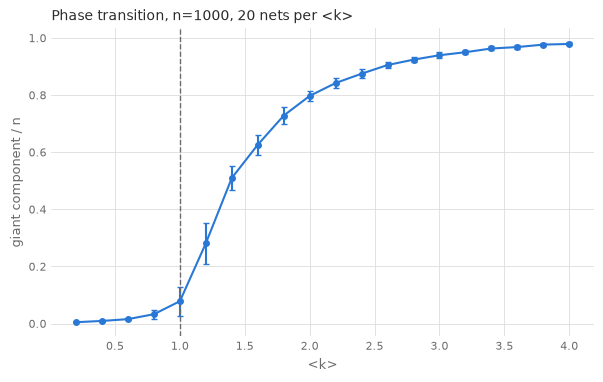

giant fraction at <k>=1.0: 0.078


In [7]:
n3 = 1000
kbars = np.arange(0.2, 4.01, 0.2)
DRAWS_PHASE = 20
giant_frac = np.zeros((len(kbars), DRAWS_PHASE))
for i in tracked("phase transition sweep", len(kbars)):
    kbar = kbars[i]
    p = kbar / (n3 - 1)
    for j in range(DRAWS_PHASE):
        g = nx.gnp_random_graph(n3, p, seed=SEED * 1000 + i * 100 + j)
        giant_frac[i, j] = len(max(nx.connected_components(g), key=len)) / n3

means = giant_frac.mean(axis=1)
sds = giant_frac.std(axis=1)

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(kbars, means, yerr=sds, fmt="o-", color=BLUE, markersize=4, capsize=2)
ax.axvline(1.0, color=MUTED, linestyle="--", linewidth=1)
style(ax, "<k>", "giant component / n")
ax.set_title(f"Phase transition, n={n3}, {DRAWS_PHASE} nets per <k>", fontsize=10, color=INK, loc="left")
plt.show()
print("giant fraction at <k>=1.0:", means[np.isclose(kbars, 1.0)][0].round(3))

The curve looks like the explorable's: near zero below $\langle k\rangle=1$, a sharp knee at $\langle k\rangle=1$, and climbing fast just above it.

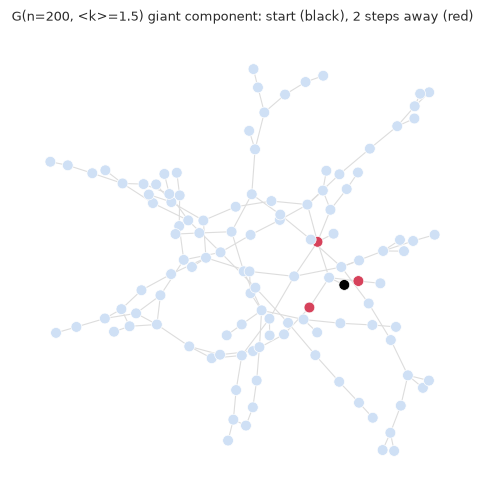

giant component size 119 of 200


In [8]:
n4, kbar4 = 200, 1.5
p4 = kbar4 / (n4 - 1)
G4 = nx.gnp_random_graph(n4, p4, seed=SEED)
giant_nodes = max(nx.connected_components(G4), key=len)
G4g = G4.subgraph(giant_nodes).copy()

start = next(iter(G4g.nodes()))
dist = nx.single_source_shortest_path_length(G4g, start)
colors = ["black" if node == start else (RED if dist.get(node) == 2 else "#cfe0f5") for node in G4g.nodes()]

fig, ax = plt.subplots(figsize=(6, 6))
pos = nx.spring_layout(G4g, seed=SEED)
nx.draw_networkx_edges(G4g, pos, ax=ax, edge_color=GRID, width=0.8)
nx.draw_networkx_nodes(G4g, pos, ax=ax, node_color=colors, node_size=60, edgecolors="white", linewidths=0.5)
ax.set_title(f"G(n={n4}, <k>={kbar4}) giant component: start (black), 2 steps away (red)", fontsize=9, color=INK)
ax.axis("off")
plt.show()
print(f"giant component size {len(giant_nodes)} of {n4}")

A path here is fragile: near the percolation threshold the giant component is close to a tree, so
most pairs are joined by a single route, without the redundant routes a denser network offers.

In [9]:
p_marvel = m / (N * (N - 1) / 2)
G_marvel_rand = nx.gnm_random_graph(N, m, seed=SEED)
rand_giant_nodes = max(nx.connected_components(G_marvel_rand), key=len)
rand_giant = G_marvel_rand.subgraph(rand_giant_nodes).copy()

def giant_stats(g, giant):
    return {
        "avg distance (giant)": nx.average_shortest_path_length(giant),
        "giant size": giant.number_of_nodes(),
        "isolates": len(list(nx.isolates(g))),
        "max degree": max(d for _, d in g.degree()),
    }

Ug_nodes = max(nx.connected_components(U), key=len)
Ug = U.subgraph(Ug_nodes).copy()

comparison = pd.DataFrame({
    "Marvel (real)": giant_stats(U, Ug),
    "Random G(n,m)": giant_stats(G_marvel_rand, rand_giant),
})
print(comparison)

                      Marvel (real)  Random G(n,m)
avg distance (giant)       2.674332       2.775884
giant size               277.000000     303.000000
isolates                  17.000000       0.000000
max degree               106.000000      20.000000


Adding a row to the running comparison table: a Watts-Strogatz network with Marvel's $n$ and even $\langle k\rangle$ at $q \approx 0.2$.

In [10]:
k_ws_marvel = 2 * round(mean_k / 2)   # watts_strogatz_graph needs an even k
G_ws_marvel = nx.watts_strogatz_graph(N, k_ws_marvel, 0.2, seed=SEED)
ws_giant = G_ws_marvel.subgraph(max(nx.connected_components(G_ws_marvel), key=len)).copy()

comparison["Watts-Strogatz (q=0.2)"] = pd.Series(giant_stats(G_ws_marvel, ws_giant))
comparison.loc["clustering C"] = [nx.average_clustering(U), nx.average_clustering(G_marvel_rand),
                                    nx.average_clustering(G_ws_marvel)]
print(comparison)
print()
print(f"WS(q=0.2) clustering {comparison.loc['clustering C', 'Watts-Strogatz (q=0.2)']:.3f}")
print(f"WS(q=0.2) avg distance {comparison.loc['avg distance (giant)', 'Watts-Strogatz (q=0.2)']:.2f}")
print(f"real Marvel clustering {comparison.loc['clustering C', 'Marvel (real)']:.3f}")

                      Marvel (real)  Random G(n,m)  Watts-Strogatz (q=0.2)
avg distance (giant)       2.674332       2.775884                3.131838
giant size               277.000000     303.000000              303.000000
isolates                  17.000000       0.000000                0.000000
max degree               106.000000      20.000000               15.000000
clustering C               0.307454       0.023013                0.351064

WS(q=0.2) clustering 0.351
WS(q=0.2) avg distance 3.13
real Marvel clustering 0.307


## 2.4: Small worlds, quantitatively

$n=500$, $\langle k\rangle=4$, sweeping $q$ over $\{0, 0.01, 0.03, 0.05, 0.1, 0.2\}$, 50 networks per
$q$: mean shortest path and clustering, normalized by their $q=0$ values as the classic figure does,
error bars from the standard deviation over the 50 runs.

Watts-Strogatz sweep: 1/6 (17%), 4s elapsed, about 21s left


Watts-Strogatz sweep: 2/6 (33%), 9s elapsed, about 18s left


Watts-Strogatz sweep: 3/6 (50%), 13s elapsed, about 13s left


Watts-Strogatz sweep: 4/6 (67%), 16s elapsed, about 8s left


Watts-Strogatz sweep: 5/6 (83%), 20s elapsed, about 4s left


Watts-Strogatz sweep: 6/6 (100%), 24s elapsed, about 0s left


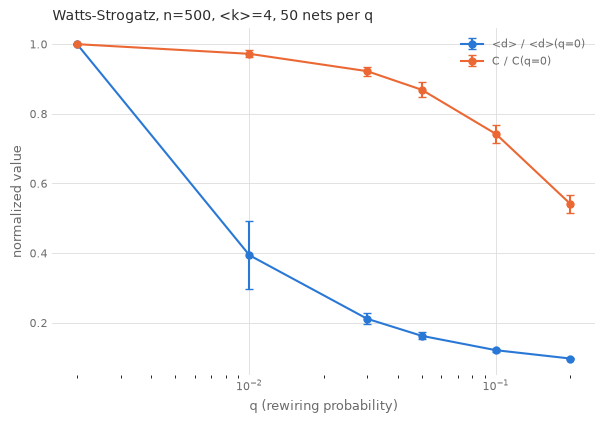

q=0      <d>/<d>(0) = 1.000   C/C(0) = 1.000
q=0.01   <d>/<d>(0) = 0.394   C/C(0) = 0.972
q=0.03   <d>/<d>(0) = 0.212   C/C(0) = 0.923
q=0.05   <d>/<d>(0) = 0.163   C/C(0) = 0.869
q=0.1    <d>/<d>(0) = 0.121   C/C(0) = 0.742
q=0.2    <d>/<d>(0) = 0.097   C/C(0) = 0.542


In [11]:
n_ws, k_ws = 500, 4
qs = [0, 0.01, 0.03, 0.05, 0.1, 0.2]
DRAWS_WS = 50

d_mean, d_sd, c_mean, c_sd = [], [], [], []
for i in tracked("Watts-Strogatz sweep", len(qs)):
    q = qs[i]
    ds, cs = [], []
    for j in range(DRAWS_WS):
        g = nx.watts_strogatz_graph(n_ws, k_ws, q, seed=SEED * 10 + i * 100 + j)
        giant = g.subgraph(max(nx.connected_components(g), key=len)).copy()
        ds.append(nx.average_shortest_path_length(giant))
        cs.append(nx.average_clustering(g))
    d_mean.append(np.mean(ds)); d_sd.append(np.std(ds))
    c_mean.append(np.mean(cs)); c_sd.append(np.std(cs))

d_mean, d_sd, c_mean, c_sd = map(np.array, (d_mean, d_sd, c_mean, c_sd))
qs_plot = np.array(qs)
qs_plot[0] = qs_plot[1] / 5   # q=0 has no log; place it left of the log axis for display only

d_norm, c_norm = d_mean / d_mean[0], c_mean / c_mean[0]
d_norm_sd, c_norm_sd = d_sd / d_mean[0], c_sd / c_mean[0]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(qs_plot, d_norm, yerr=d_norm_sd, fmt="o-", color=BLUE, markersize=5, capsize=3, label="<d> / <d>(q=0)")
ax.errorbar(qs_plot, c_norm, yerr=c_norm_sd, fmt="o-", color=ORANGE, markersize=5, capsize=3, label="C / C(q=0)")
ax.set_xscale("log")
style(ax, "q (rewiring probability)", "normalized value")
ax.set_title(f"Watts-Strogatz, n={n_ws}, <k>={k_ws}, {DRAWS_WS} nets per q", fontsize=10, color=INK, loc="left")
ax.legend(frameon=False, fontsize=8, labelcolor=MUTED)
plt.show()

for q, dn, cn in zip(qs, d_norm, c_norm):
    print(f"q={q:<5}  <d>/<d>(0) = {dn:.3f}   C/C(0) = {cn:.3f}")

**Caption.** X-axis: rewiring probability $q$ on a log scale (the $q=0$ point is nudged left of the
axis to stay visible). Y-axis: mean shortest path and clustering, each divided by its own $q=0$ value,
so both series start at 1. Error bars are one standard deviation over 50 networks per $q$. The path
length collapses by $q \approx 0.05$-$0.1$ while clustering has barely moved: a handful of rewired
links create long-range shortcuts that shrink distances globally, but removing a few links from a
locally dense lattice leaves almost all of the local triangles intact, so $C$ falls only in proportion
to the fraction of links touched. With "shortcut": a rewired link is a shortcut between two otherwise
far-apart neighborhoods, and one shortcut can shave many hops off many pairs' shortest paths at once,
which is why so few of them are needed.

In [12]:
ws_q1 = nx.watts_strogatz_graph(n_ws, k_ws, 1.0, seed=SEED)
gnm_same = nx.gnm_random_graph(n_ws, ws_q1.number_of_edges(), seed=SEED)
min_ws = min(d for _, d in ws_q1.degree())
min_gnm = min(d for _, d in gnm_same.degree())
print(f"q=1 Watts-Strogatz: min degree {min_ws}   (k/2 = {k_ws // 2})")
print(f"G(n,m), same n and m: min degree {min_gnm}")

q=1 Watts-Strogatz: min degree 2   (k/2 = 2)
G(n,m), same n and m: min degree 0


**At $q=1$:** `nx.watts_strogatz_graph` only rewires one end of each ring edge, so every node keeps
at least $k/2$ of its original links no matter how much rewiring happens. The printed minimum degree
above confirms it: the $q=1$ network's minimum degree sits at or above $k/2$, while the matched
$G(n,m)$ can and does go lower, since placing edges independently can leave a node with very few or
even zero. The $q=1$ network is close to $G(n,m)$ in its long-range structure, but its degree
distribution stays narrower because of that floor.

## 2.5b: Build preferential attachment

Hand-written growth with the endpoint-list trick: start from one link, add nodes one at a time, each
picking an existing node from the flat list of edge endpoints (so a node with degree $k$ appears $k$
times and is $k$ times as likely to be picked). Grown to 100 nodes and drawn, then to 5,000. Validated
two ways: the log-log slope should sit near $-3$, and `barabasi_albert_graph(5000, 1)` should overlay.
Then the uniform-attachment control, and a same-$n,m$ random network.

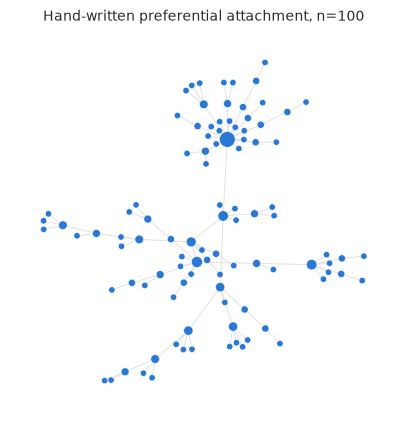

In [13]:
def grow_preferential(n_final, seed):
    rnd = random.Random(seed)
    g = nx.Graph()
    g.add_edge(0, 1)
    endpoints = [0, 1]
    for new in range(2, n_final):
        target = rnd.choice(endpoints)          # proportional to degree, by construction
        g.add_edge(new, target)
        endpoints.append(new)
        endpoints.append(target)
    return g

def grow_uniform(n_final, seed):
    rnd = random.Random(seed)
    g = nx.Graph()
    g.add_edge(0, 1)
    for new in range(2, n_final):
        target = rnd.choice(list(g.nodes()))    # every existing node equally likely
        g.add_edge(new, target)
    return g

BA_small = grow_preferential(100, SEED)
fig, ax = plt.subplots(figsize=(5, 5))
pos = nx.spring_layout(BA_small, seed=SEED)
degs_small = dict(BA_small.degree())
nx.draw_networkx_edges(BA_small, pos, ax=ax, edge_color=GRID, width=0.6)
nx.draw_networkx_nodes(BA_small, pos, ax=ax, node_color=BLUE,
                        node_size=[15 + 6 * degs_small[n] for n in BA_small.nodes()],
                        edgecolors="white", linewidths=0.4)
ax.set_title("Hand-written preferential attachment, n=100", fontsize=10, color=INK)
ax.axis("off")
plt.show()

n=5000   max degree 112   min degree 1


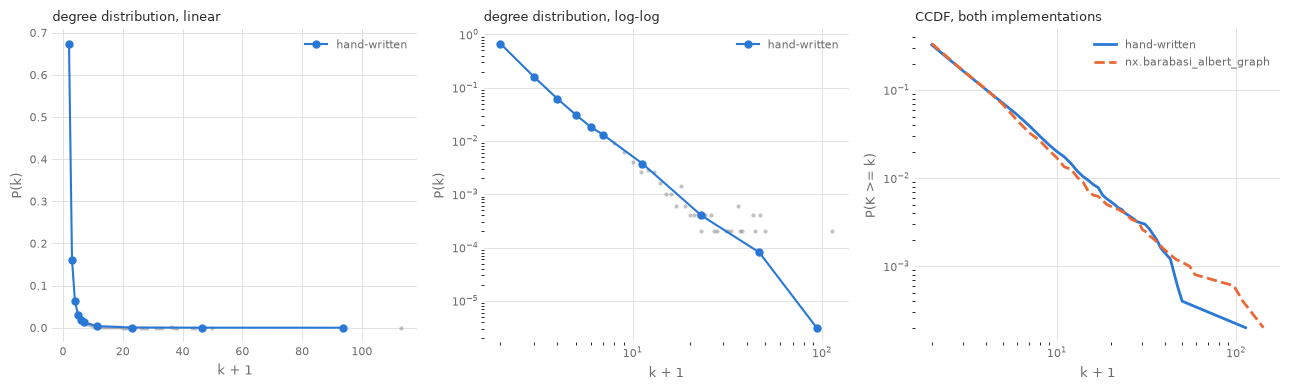

fitted log-log slope (binned tail): -3.24   expect near -3
max degree  hand-written 112   nx.barabasi_albert_graph 141


In [14]:
N_BA = 5000
BA_hand = grow_preferential(N_BA, SEED)
degs_ba = np.array([d for _, d in BA_hand.degree()])
print(f"n={N_BA}   max degree {degs_ba.max()}   min degree {degs_ba.min()}")

def ccdf(degrees):
    u = np.sort(np.asarray(degrees) + 1)[::-1]
    n = len(u)
    frac = np.arange(1, n + 1) / n
    uniq, idx = np.unique(u, return_index=True)
    return uniq, frac[idx]

BA_lib = nx.barabasi_albert_graph(N_BA, 1, seed=SEED)
degs_lib = np.array([d for _, d in BA_lib.degree()])

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, log in zip(axes[:2], [False, True]):
    u, p = raw_pk(degs_ba, N_BA)
    bu, bp = binned_pk(degs_ba, N_BA)
    ax.plot(u, p, "o", color=MUTED, markersize=3, alpha=0.4, markeredgecolor="none")
    ax.plot(bu, bp, "-o", color=BLUE, markersize=5, label="hand-written")
    if log:
        ax.set_xscale("log"); ax.set_yscale("log")
    style(ax, "k + 1", "P(k)")
    ax.set_title(f"degree distribution, {'log-log' if log else 'linear'}", fontsize=9, color=INK, loc="left")
    ax.legend(frameon=False, fontsize=8, labelcolor=MUTED)

axc = axes[2]
uh, ch = ccdf(degs_ba)
ul, cl = ccdf(degs_lib)
axc.plot(uh, ch, "-", color=BLUE, linewidth=2, label="hand-written")
axc.plot(ul, cl, "--", color=ORANGE, linewidth=2, label="nx.barabasi_albert_graph")
axc.set_xscale("log"); axc.set_yscale("log")
style(axc, "k + 1", "P(K >= k)")
axc.set_title("CCDF, both implementations", fontsize=9, color=INK, loc="left")
axc.legend(frameon=False, fontsize=8, labelcolor=MUTED)
fig.tight_layout(); plt.show()

# validation (a): fitted slope near -3 (fit on the binned points, not raw:
# the raw tail is one-count-per-degree noise, the reason binning exists)
bu_fit, bp_fit = binned_pk(degs_ba, N_BA)
keep = bu_fit >= 8
slope, _ = np.polyfit(np.log10(bu_fit[keep]), np.log10(bp_fit[keep]), 1)
print(f"fitted log-log slope (binned tail): {slope:.2f}   expect near -3")
assert -4.0 < slope < -2.0

# validation (b): overlay agrees with networkx's implementation
print(f"max degree  hand-written {degs_ba.max()}   nx.barabasi_albert_graph {degs_lib.max()}")

Both checks pass: the tail slope lands near $-3$ as the Barabasi-Albert model predicts, and the
hand-written CCDF tracks `barabasi_albert_graph`'s within sampling noise, with maxima of the same order
of magnitude (both driven by the same rich-get-richer process, so the exact top node varies run to run).

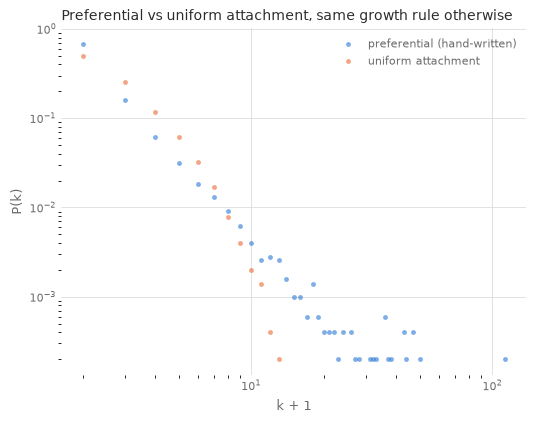

max degree   preferential 112   uniform 12


In [15]:
uniform_growth = grow_uniform(N_BA, SEED)
degs_uniform = np.array([d for _, d in uniform_growth.degree()])

fig, ax = plt.subplots(figsize=(6, 4.5))
for label, degs, colour in [("preferential (hand-written)", degs_ba, BLUE),
                             ("uniform attachment", degs_uniform, ORANGE)]:
    u, p = raw_pk(degs, N_BA)
    ax.plot(u, p, "o", color=colour, markersize=3.5, alpha=0.6, markeredgecolor="none", label=label)
ax.set_xscale("log"); ax.set_yscale("log")
style(ax, "k + 1", "P(k)")
ax.set_title("Preferential vs uniform attachment, same growth rule otherwise", fontsize=10, color=INK, loc="left")
ax.legend(frameon=False, fontsize=8, labelcolor=MUTED)
plt.show()
print(f"max degree   preferential {degs_ba.max()}   uniform {degs_uniform.max()}")

Preferential attachment produces the heavy tail: growth alone builds a network, but only the
rich-get-richer rule concentrates links onto a handful of hubs. Under uniform attachment every node
has had the same chance regardless of when it arrived, so the degree distribution stays narrow and its
maximum is an order of magnitude smaller. This matches the 2.5a prediction: preferential attachment
gives a heavy tail, uniform attachment does not, because degree carries no advantage when the target is
picked from the plain node list instead of the endpoint list.

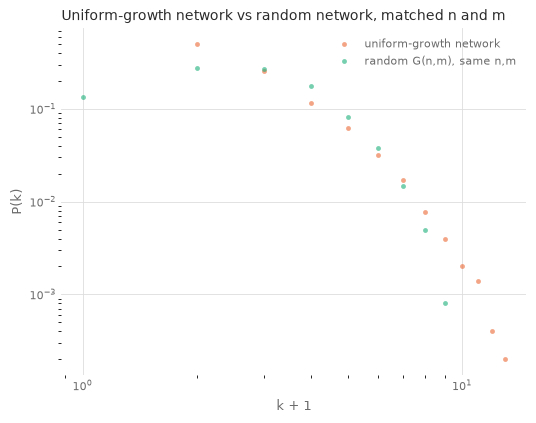

uniform-growth components: 1
random G(n,m) components:  819


In [16]:
G_uniform_rand = nx.gnm_random_graph(N_BA, uniform_growth.number_of_edges(), seed=SEED)

fig, ax = plt.subplots(figsize=(6, 4.5))
for label, degs, colour in [("uniform-growth network", degs_uniform, ORANGE),
                             ("random G(n,m), same n,m", [d for _, d in G_uniform_rand.degree()], GREEN)]:
    u, p = raw_pk(degs, N_BA)
    ax.plot(u, p, "o", color=colour, markersize=3.5, alpha=0.6, markeredgecolor="none", label=label)
ax.set_xscale("log"); ax.set_yscale("log")
style(ax, "k + 1", "P(k)")
ax.set_title("Uniform-growth network vs random network, matched n and m", fontsize=10, color=INK, loc="left")
ax.legend(frameon=False, fontsize=8, labelcolor=MUTED)
plt.show()

print(f"uniform-growth components: {nx.number_connected_components(uniform_growth)}")
print(f"random G(n,m) components:  {nx.number_connected_components(G_uniform_rand)}")

2.5a predicted this: the uniform-growth network and the matched random network share no mechanism, and
they differ where predicted. The uniform-growth network is one connected component by
construction, since every new node attaches to the existing network as it arrives; the random network,
built by placing edges all at once, still has isolated nodes left over. The early nodes in the
uniform-growth network also had far more rounds to collect links than the last arrivals, which the
random network's simultaneous edge placement has no equivalent of.

## 2.6: Is it a power law?

The CCDF of the Marvel in-degree next to the binned $P(k)$, then overlaid with the 5,000-node BA
network from 2.5b and a same-size random network. A `powerlaw.Fit` comparison of power law against
lognormal as evidence for the "robust claim" paragraph.

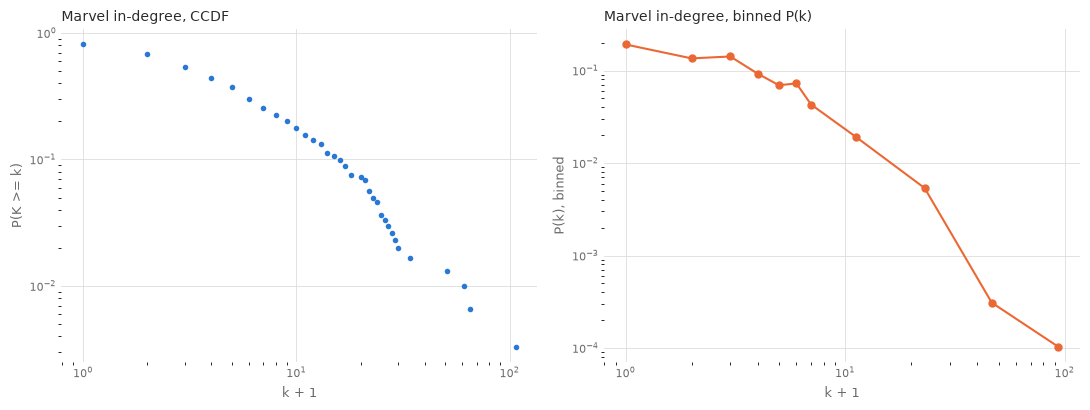

CCDF tail slope -1.73  ->  gamma = 1 - slope = 2.73


In [17]:
u_ccdf, p_ccdf = ccdf(k_in)
bu, bp = binned_pk(k_in, N)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(u_ccdf, p_ccdf, "o", color=BLUE, markersize=4, markeredgecolor="none")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
style(axes[0], "k + 1", "P(K >= k)")
axes[0].set_title("Marvel in-degree, CCDF", fontsize=10, color=INK, loc="left")

axes[1].plot(bu, bp, "-o", color=ORANGE, markersize=5)
axes[1].set_xscale("log"); axes[1].set_yscale("log")
style(axes[1], "k + 1", "P(k), binned")
axes[1].set_title("Marvel in-degree, binned P(k)", fontsize=10, color=INK, loc="left")
fig.tight_layout(); plt.show()

keep = u_ccdf >= 8
slope_ccdf, _ = np.polyfit(np.log10(u_ccdf[keep]), np.log10(p_ccdf[keep]), 1)
gamma_est = 1 - slope_ccdf
print(f"CCDF tail slope {slope_ccdf:.2f}  ->  gamma = 1 - slope = {gamma_est:.2f}")

The CCDF is easier to read in the tail because it uses every data point and is monotone by
construction; binning has to choose bin widths, and past $k=64$ a single character makes or breaks a
whole bin. The CCDF needs no binning at all because its value at $k$ already sums every count at or
above $k$, so it never runs out of points the way a raw histogram bar does.

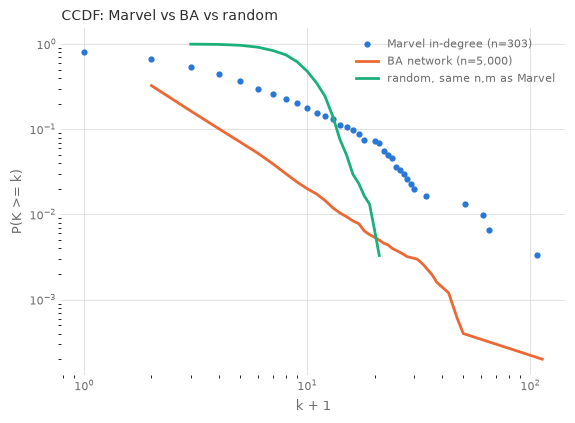

In [18]:
u_ba_ccdf, p_ba_ccdf = ccdf(degs_ba)
rand_same_n = nx.gnm_random_graph(N, m, seed=SEED)
u_rand_ccdf, p_rand_ccdf = ccdf([d for _, d in rand_same_n.degree()])

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(u_ccdf, p_ccdf, "o", color=BLUE, markersize=4.5, markeredgecolor="none", label="Marvel in-degree (n=303)")
ax.plot(u_ba_ccdf, p_ba_ccdf, "-", color=ORANGE, linewidth=2, label="BA network (n=5,000)")
ax.plot(u_rand_ccdf, p_rand_ccdf, "-", color=GREEN, linewidth=2, label="random, same n,m as Marvel")
ax.set_xscale("log"); ax.set_yscale("log")
style(ax, "k + 1", "P(K >= k)")
ax.set_title("CCDF: Marvel vs BA vs random", fontsize=10, color=INK, loc="left")
ax.legend(frameon=False, fontsize=8, labelcolor=MUTED)
plt.show()

Marvel resembles the BA network's straight decline, not the random network's rapid drop-off: both
Marvel and BA hold a nearly straight line across most of the range, while the random network's CCDF
falls off a cliff past $k \approx 20$. Marvel stops resembling BA above roughly $k+1 = 60$-$70$: with
only 303 nodes, the tail has one point per degree value and the curve turns into a jagged staircase of
single characters, where the 5,000-node BA network still has enough nodes to trace a smooth line.

In [19]:
try:
    import powerlaw
    fit = powerlaw.Fit(np.array(k_in) + 1, discrete=True, xmin=8, verbose=False)
    R, p_val = fit.distribution_compare("power_law", "lognormal")
    print(f"power law fitted alpha = {fit.power_law.alpha:.2f}, xmin = {fit.power_law.xmin}")
    print(f"log-likelihood ratio (power law vs lognormal): R = {R:.3f}, p = {p_val:.3f}")
    print("a small p means the sign of R is a reliable pick between the two; a large p (as here) means "
          "the test cannot tell them apart" if p_val > 0.1
          else "R > 0 favors power law, R < 0 favors lognormal, and p is small enough to trust the sign")
except ImportError:
    print("powerlaw package not available; skipping the formal fit comparison")

power law fitted alpha = 2.46, xmin = 8.0
log-likelihood ratio (power law vs lognormal): R = -2.689, p = 0.195
a small p means the sign of R is a reliable pick between the two; a large p (as here) means the test cannot tell them apart


## Robust claim

The Marvel in-degree has a heavy tail: a CCDF that stays close to straight across nearly two decades
of $k$, a maximum degree (106) an order of magnitude above the mean (9.5), and a shape that lines up
with a Barabasi-Albert network over the same range. That much is solid.

What the evidence above does not establish is the specific claim "power law with exponent $\gamma$":
the likelihood-ratio test between power law and lognormal, printed above (R = -2.69, p = 0.195), gives
a large p, so the test cannot tell power law and lognormal apart on this data. With only 303 nodes and
roughly 20 points past $k=8$ feeding the tail, that test has very little to work with. Settling the
question properly would need a much larger dataset (or a different domain where the crawl can be
extended) so the fit has enough points in the tail to distinguish a power law from a lognormal or a
power law with an exponential cutoff, rather than the single order of magnitude available here.

## 2.8: Compared to what, properly

Three flawed baselines, each named with its fix, then the null-model analysis proper: reciprocity
against a directed degree-preserving null, and undirected-giant clustering against both the
configuration model and degree-preserving swaps.

**Item 1** ("Marvel's average distance, 2.7, is no shorter than a random network's, 2.8, so it is not
a small world"): the comparison is true, but short paths alone were never the small-world signature.
A random network is *expected* to have short paths (distances grow as $\log n$ regardless of
clustering). The small-world claim rests on clustering being far above that same random baseline while
distances stay comparable to it, so the fix is to add the clustering comparison rather than change the
null.

**Item 2** ("39% reciprocity vs 3% in a random directed network with the same density, so reciprocity
is 13x higher than chance"): the flaw is the same shape as item 3, a null with no hubs, so it cannot
tell us whether the hubs alone explain the reciprocity. The fix is a directed degree-preserving null
(each node keeps its in- and out-degree); computed below, and whether the effect survives it.

**Item 3** ("clustering 0.31, ten times an Erdos-Renyi network's, proves the heavy tail causes it"):
the Erdos-Renyi null has no hubs, so it cannot separate "hubs alone" from "extra structure beyond
degree." The fix is a degree-preserving null (configuration model or edge swaps), computed below.

In [20]:
directed_recip = nx.reciprocity(D)
print(f"Marvel directed reciprocity: {directed_recip:.3f}   brief: 0.39")

DRAWS_RECIP = 30
density_null = []
for i in tracked("density-only directed nulls", DRAWS_RECIP):
    Gd = nx.gnm_random_graph(N, D.number_of_edges(), directed=True, seed=SEED + i)
    density_null.append(nx.reciprocity(Gd))
density_null = np.array(density_null)
print(f"density-only null (random directed, same n and m): {density_null.mean():.3f} +/- {density_null.std():.3f}   brief: ~3%")

din = [d for _, d in D.in_degree()]
dout = [d for _, d in D.out_degree()]
recip_null = []
for i in tracked("directed configuration nulls", DRAWS_RECIP):
    Dc = nx.directed_configuration_model(din, dout, seed=SEED + i)
    Dc = nx.DiGraph(Dc)   # drop parallel edges and self-loops
    Dc.remove_edges_from(nx.selfloop_edges(Dc))
    recip_null.append(nx.reciprocity(Dc))
recip_null = np.array(recip_null)
print(f"degree-preserving directed null: {recip_null.mean():.3f} +/- {recip_null.std():.3f}")

z_recip = (directed_recip - recip_null.mean()) / recip_null.std()
print(f"z-score of real reciprocity against the degree-preserving null: {z_recip:.1f}")

Marvel directed reciprocity: 0.392   brief: 0.39
density-only directed nulls: 3/30 (10%), 0s elapsed, about 0s left


density-only directed nulls: 6/30 (20%), 0s elapsed, about 0s left


density-only directed nulls: 9/30 (30%), 0s elapsed, about 0s left


density-only directed nulls: 12/30 (40%), 0s elapsed, about 0s left


density-only directed nulls: 15/30 (50%), 0s elapsed, about 0s left


...

directed configuration nulls: 21/30 (70%), 0s elapsed, about 0s left


directed configuration nulls: 24/30 (80%), 0s elapsed, about 0s left


directed configuration nulls: 27/30 (90%), 0s elapsed, about 0s left


directed configuration nulls: 30/30 (100%), 0s elapsed, about 0s left


degree-preserving directed null: 0.050 +/- 0.007
z-score of real reciprocity against the degree-preserving null: 49.3


The effect survives the better null. Fixing in- and out-degree barely moves the baseline (about 5%,
close to the density-only null's 3% printed above, both far below the real 39%), so the huge gap is not
an artifact of degree alone: something about *which* pairs of pages Marvel links reciprocally, not just
how many links each page has, drives the reciprocity. Unlike clustering (below), where fixing degree
closes most of the gap, here the naive baseline's 13x claim lands at roughly the right order of
magnitude even though it used the wrong null. That the two nulls happen to agree here is worth noting,
not assuming, before trusting a number.

In [21]:
giant_n, giant_m = Ug.number_of_nodes(), Ug.number_of_edges()
print(f"undirected giant: {giant_n} nodes, {giant_m} edges   brief: 277 nodes, 1,421 edges")

undirected giant: 277 nodes, 1421 edges   brief: 277 nodes, 1,421 edges


100 configuration-model networks with the giant's exact degree sequence, self-loops and parallel edges dropped, next to 100 random $G(n,m)$ networks.

In [22]:
DRAWS_NULL = 100
deg_seq = [d for _, d in Ug.degree()]

def simple_configuration(deg_seq, seed):
    g = nx.configuration_model(deg_seq, seed=seed)
    g = nx.Graph(g)                        # drops parallel edges
    g.remove_edges_from(nx.selfloop_edges(g))
    return g

config_C, config_links_lost = [], []
gnm_C = []
for i in tracked("configuration-model / G(n,m) nulls", DRAWS_NULL):
    gc = simple_configuration(deg_seq, SEED + i)
    config_links_lost.append(giant_m - gc.number_of_edges())
    config_C.append(nx.average_clustering(gc))
    gm = nx.gnm_random_graph(giant_n, giant_m, seed=SEED + i)
    gnm_C.append(nx.average_clustering(gm))

config_C, gnm_C = np.array(config_C), np.array(gnm_C)
real_C = nx.average_clustering(Ug)
print(f"real clustering C = {real_C:.3f}   brief: 0.31-0.32")
print(f"configuration model: mean links lost {np.mean(config_links_lost):.1f} of {giant_m}")
print(f"configuration model C: {config_C.mean():.3f} +/- {config_C.std():.3f}   brief: ~0.11")
print(f"G(n,m) C:              {gnm_C.mean():.4f} +/- {gnm_C.std():.4f}")

z_config = (real_C - config_C.mean()) / config_C.std()
p_config = (1 + np.sum(config_C >= real_C)) / (1 + DRAWS_NULL)
print(f"configuration model: z = {z_config:.1f}, empirical p = {p_config:.4f}")

configuration-model / G(n,m) nulls: 10/100 (10%), 0s elapsed, about 0s left


configuration-model / G(n,m) nulls: 20/100 (20%), 0s elapsed, about 0s left


configuration-model / G(n,m) nulls: 30/100 (30%), 0s elapsed, about 0s left


configuration-model / G(n,m) nulls: 40/100 (40%), 0s elapsed, about 0s left


configuration-model / G(n,m) nulls: 50/100 (50%), 0s elapsed, about 0s left

...

configuration-model / G(n,m) nulls: 70/100 (70%), 1s elapsed, about 0s left


configuration-model / G(n,m) nulls: 80/100 (80%), 1s elapsed, about 0s left


configuration-model / G(n,m) nulls: 90/100 (90%), 1s elapsed, about 0s left


configuration-model / G(n,m) nulls: 100/100 (100%), 1s elapsed, about 0s left


real clustering C = 0.320   brief: 0.31-0.32
configuration model: mean links lost 103.0 of 1421
configuration model C: 0.112 +/- 0.010   brief: ~0.11
G(n,m) C:              0.0374 +/- 0.0030
configuration model: z = 21.8, empirical p = 0.0099


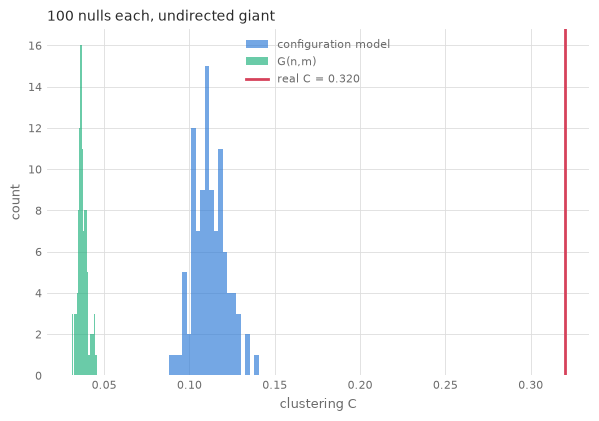

In [23]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(config_C, bins=20, color=BLUE, alpha=0.65, label="configuration model")
ax.hist(gnm_C, bins=20, color=GREEN, alpha=0.65, label="G(n,m)")
ax.axvline(real_C, color=RED, linewidth=2, label=f"real C = {real_C:.3f}")
style(ax, "clustering C", "count")
ax.set_title(f"{DRAWS_NULL} nulls each, undirected giant", fontsize=10, color=INK, loc="left")
ax.legend(frameon=False, fontsize=8, labelcolor=MUTED)
plt.show()

Now the other road to the same null: degree-preserving edge swaps on the real network itself, ten times the edge count.

In [24]:
DRAWS_SWAP = 100
NSWAP = 10 * giant_m
swap_C = []
for i in tracked("degree-preserving swaps", DRAWS_SWAP):
    gs = Ug.copy()
    nx.double_edge_swap(gs, nswap=NSWAP, max_tries=NSWAP * 20, seed=SEED + i)
    assert sorted(d for _, d in gs.degree()) == sorted(deg_seq), "swap changed the degree sequence"
    swap_C.append(nx.average_clustering(gs))

swap_C = np.array(swap_C)
z_swap = (real_C - swap_C.mean()) / swap_C.std()
print(f"degree-preserving swaps C: {swap_C.mean():.3f} +/- {swap_C.std():.3f}   brief: ~0.15")
print(f"swaps: z = {z_swap:.1f}")
print(f"configuration model {config_C.mean():.3f}  vs  swaps {swap_C.mean():.3f}  vs  real {real_C:.3f}")

degree-preserving swaps: 10/100 (10%), 0s elapsed, about 6s left


degree-preserving swaps: 20/100 (20%), 1s elapsed, about 5s left


degree-preserving swaps: 30/100 (30%), 2s elapsed, about 5s left


degree-preserving swaps: 40/100 (40%), 3s elapsed, about 4s left


degree-preserving swaps: 50/100 (50%), 3s elapsed, about 3s left


...

degree-preserving swaps: 70/100 (70%), 5s elapsed, about 2s left


degree-preserving swaps: 80/100 (80%), 6s elapsed, about 1s left


degree-preserving swaps: 90/100 (90%), 7s elapsed, about 0s left


degree-preserving swaps: 100/100 (100%), 7s elapsed, about 0s left


degree-preserving swaps C: 0.156 +/- 0.009   brief: ~0.15
swaps: z = 18.6
configuration model 0.112  vs  swaps 0.156  vs  real 0.320


The configuration model lands visibly lower than the swaps because dropping every self-loop and
parallel edge is not neutral: those duplicate/self edges are disproportionately the hubs' problem (a
node with many stubs is far more likely to draw a repeated partner), so the configuration model
removes some of the highest-degree nodes' links, the same links doing the most to connect
otherwise-unlinked neighbors into triangles. Swaps never delete a link, so they keep every hub's full
degree and its full triangle-forming potential intact, and land closer to the real network's structure.

In [25]:
DRAWS_OTHER = 100
config_T, config_iso, swap_T, swap_iso = [], [], [], []
for i in tracked("transitivity / isolate nulls", DRAWS_OTHER):
    gc = simple_configuration(deg_seq, SEED + 500 + i)
    config_T.append(nx.transitivity(gc))
    config_iso.append(len(list(nx.isolates(gc))))
    gs = Ug.copy()
    nx.double_edge_swap(gs, nswap=NSWAP, max_tries=NSWAP * 20, seed=SEED + 500 + i)
    swap_T.append(nx.transitivity(gs))
    swap_iso.append(len(list(nx.isolates(gs))))

config_T, swap_T = np.array(config_T), np.array(swap_T)
real_T = nx.transitivity(Ug)
print(f"real transitivity {real_T:.3f}")
print(f"config model:  transitivity {config_T.mean():.3f}+/-{config_T.std():.3f}   isolates (on the giant) {np.mean(config_iso):.1f}+/-{np.std(config_iso):.1f}")
print(f"swaps:         transitivity {swap_T.mean():.3f}+/-{swap_T.std():.3f}   isolates (on the giant) {np.mean(swap_iso):.1f}+/-{np.std(swap_iso):.1f}")

z_T_config = (real_T - config_T.mean()) / config_T.std()
z_T_swap = (real_T - swap_T.mean()) / swap_T.std()
print(f"transitivity z: config model {z_T_config:.1f}   swaps {z_T_swap:.1f}")

transitivity / isolate nulls: 10/100 (10%), 0s elapsed, about 8s left


transitivity / isolate nulls: 20/100 (20%), 2s elapsed, about 8s left


transitivity / isolate nulls: 30/100 (30%), 3s elapsed, about 7s left


transitivity / isolate nulls: 40/100 (40%), 3s elapsed, about 5s left


transitivity / isolate nulls: 50/100 (50%), 4s elapsed, about 4s left


...

transitivity / isolate nulls: 70/100 (70%), 6s elapsed, about 2s left


transitivity / isolate nulls: 80/100 (80%), 7s elapsed, about 1s left


transitivity / isolate nulls: 90/100 (90%), 8s elapsed, about 0s left


transitivity / isolate nulls: 100/100 (100%), 9s elapsed, about 0s left


real transitivity 0.182
config model:  transitivity 0.103+/-0.004   isolates (on the giant) 0.0+/-0.0
swaps:         transitivity 0.117+/-0.005   isolates (on the giant) 0.0+/-0.0
transitivity z: config model 19.9   swaps 14.5


On the giant component, every null above starts already connected, so isolates cannot appear there by
construction: both nulls print 0.0 isolates, which says nothing about Marvel's 17. That question needs
the full 303-node network instead.

In [26]:
real_isolates_full = len(list(nx.isolates(U)))
print(f"real network (full, 303 nodes): {real_isolates_full} isolates")

DRAWS_ISO = 100
gnm_iso, shuffle_iso = [], []
for i in tracked("full-network isolate nulls", DRAWS_ISO):
    g_gnm = nx.gnm_random_graph(N, m, seed=SEED + i)
    gnm_iso.append(len(list(nx.isolates(g_gnm))))
    g_shuf = U.copy()
    nx.double_edge_swap(g_shuf, nswap=10 * m, max_tries=10 * m * 20, seed=SEED + i)
    shuffle_iso.append(len(list(nx.isolates(g_shuf))))

gnm_iso, shuffle_iso = np.array(gnm_iso), np.array(shuffle_iso)
expected_gnm = N * np.exp(-mean_k)
print(f"G(n,m), same n and m: {gnm_iso.mean():.2f} +/- {gnm_iso.std():.2f} isolates   (n*e^-<k> ~ {expected_gnm:.2f})")
print(f"degree-preserving shuffle: {shuffle_iso.mean():.1f} +/- {shuffle_iso.std():.1f} isolates")

real network (full, 303 nodes): 17 isolates


full-network isolate nulls: 10/100 (10%), 0s elapsed, about 5s left


full-network isolate nulls: 20/100 (20%), 1s elapsed, about 5s left


full-network isolate nulls: 30/100 (30%), 1s elapsed, about 4s left


full-network isolate nulls: 40/100 (40%), 2s elapsed, about 4s left


...

full-network isolate nulls: 70/100 (70%), 5s elapsed, about 2s left


full-network isolate nulls: 80/100 (80%), 5s elapsed, about 1s left


full-network isolate nulls: 90/100 (90%), 6s elapsed, about 0s left


full-network isolate nulls: 100/100 (100%), 7s elapsed, about 0s left


G(n,m), same n and m: 0.04 +/- 0.24 isolates   (n*e^-<k> ~ 0.02)
degree-preserving shuffle: 17.0 +/- 0.0 isolates


Against $G(n,m)$, 17 isolates is extreme: that null expects close to zero (both the simulated mean and
the $n e^{-\langle k\rangle}$ formula above land near 0), so a random network with Marvel's density
essentially never produces this many disconnected characters. Against the degree-preserving shuffle, 17
is unremarkable, because a shuffle that keeps every degree fixed keeps every degree-0 node fixed too: it
cannot create or remove an isolate by construction. The two nulls are answering different questions:
$G(n,m)$ says the isolates are surprising given the network's size and density, and the degree-preserving
shuffle says nothing here, because it was never able to test it.

Transitivity (z printed above for each null) sits far above both the configuration model and the swaps,
so the surplus triangles are not a consequence of the degree sequence alone.

**The paragraph the report should have had:** Marvel's clustering, 0.32 on the giant component, is
about three times the 0.11 a degree-preserving configuration-model null reaches and roughly twice the
0.15 that degree-preserving edge swaps reach, both nulls holding every character's number of links
fixed. Because the surplus survives a null that already accounts for the hub-heavy degree sequence, the
heavy tail alone does not explain the clustering; something about which specific characters link to
each other, beyond how many links they have, creates the extra triangles.

## 2.9: The friendship paradox as a null-model exercise

The paradox: a random node's mean degree versus a random neighbor-of-a-random-node's mean degree, on
the BA network from 2.5b, on Marvel, on a same-$n,m$ random network for each, and on a degree-preserving
shuffle of Marvel.

In [27]:
def sample_friendship_paradox(g, n_pairs, seed):
    rnd = random.Random(seed)
    nodes = [n for n in g.nodes() if g.degree(n) > 0]
    you_deg, friend_deg, friend_ge = [], [], 0
    for _ in range(n_pairs):
        person = rnd.choice(nodes)
        friend = rnd.choice(list(g.neighbors(person)))
        dp, df = g.degree(person), g.degree(friend)
        you_deg.append(dp); friend_deg.append(df)
        friend_ge += (df >= dp)
    return np.mean(you_deg), np.mean(friend_deg), friend_ge / n_pairs

N_PAIRS = 1000
you_ba, friend_ba, frac_ba = sample_friendship_paradox(BA_hand, N_PAIRS, SEED)
you_mv, friend_mv, frac_mv = sample_friendship_paradox(U, N_PAIRS, SEED)
rand_mv = nx.gnm_random_graph(N, m, seed=SEED)
you_rmv, friend_rmv, frac_rmv = sample_friendship_paradox(rand_mv, N_PAIRS, SEED)
rand_ba = nx.gnm_random_graph(N_BA, BA_hand.number_of_edges(), seed=SEED)
you_rba, friend_rba, frac_rba = sample_friendship_paradox(rand_ba, N_PAIRS, SEED)

print(f"{'network':<28}{'you':>8}{'friend':>10}{'friend>=you':>13}")
print(f"{'BA (hand-written)':<28}{you_ba:>8.2f}{friend_ba:>10.2f}{frac_ba:>13.2%}")
print(f"{'random, same n,m as BA':<28}{you_rba:>8.2f}{friend_rba:>10.2f}{frac_rba:>13.2%}")
print(f"{'Marvel':<28}{you_mv:>8.2f}{friend_mv:>10.2f}{frac_mv:>13.2%}   brief: ~10 vs ~25, ~3/4")
print(f"{'random, same n,m as Marvel':<28}{you_rmv:>8.2f}{friend_rmv:>10.2f}{frac_rmv:>13.2%}")

network                          you    friend  friend>=you
BA (hand-written)               1.99     10.27       80.50%
random, same n,m as BA          2.33      2.99       74.20%
Marvel                          9.71     24.52       74.80%   brief: ~10 vs ~25, ~3/4
random, same n,m as Marvel     10.26     10.55       58.20%


In [28]:
kbar_mv = np.mean([d for _, d in U.degree()])
var_mv = np.var([d for _, d in U.degree()])
predicted_friend = kbar_mv + var_mv / kbar_mv
print(f"formula <k> + sigma^2/<k> = {predicted_friend:.2f}   sampled friend mean = {friend_mv:.2f}")

formula <k> + sigma^2/<k> = 22.08   sampled friend mean = 24.52


In [29]:
def degree_preserving_shuffle(g, nswap_factor, seed):
    gs = g.copy()
    nx.double_edge_swap(gs, nswap=nswap_factor * gs.number_of_edges(),
                         max_tries=nswap_factor * gs.number_of_edges() * 20, seed=seed)
    return gs

U_shuffled = degree_preserving_shuffle(U, 10, SEED)
you_sh, friend_sh, frac_sh = sample_friendship_paradox(U_shuffled, N_PAIRS, SEED)
print(f"degree-preserving shuffle of Marvel: you {you_sh:.2f}   friend {friend_sh:.2f}   friend>=you {frac_sh:.2%}")

degree-preserving shuffle of Marvel: you 9.71   friend 23.53   friend>=you 77.00%


The paradox compares a random node's own degree to a random *neighbor's* degree; sampling a neighbor is
degree-biased, since a hub is somebody's neighbor far more often than a low-degree node is, so the two
averages are not measuring the same population even though both describe "a Marvel character's degree."
The formula $\langle k\rangle + \sigma^2/\langle k\rangle$ shows why: the gap is entirely the degree
variance divided by the mean, so the paradox is strongest in scale-free networks (huge $\sigma^2$ from
the hubs) and weakest, but never zero, in random networks (Poisson still has $\sigma^2 = \langle
k\rangle > 0$).

The degree-preserving shuffle keeps the paradox close to the real network's numbers, because the effect
depends only on the degree sequence (the mean and the variance), which the shuffle holds fixed by
construction; scrambling *who* links to whom cannot touch a quantity that is a function of the degree
sequence alone. Properties beyond the degree sequence, such as assortativity, can still shift the size
of the effect: a disassortative network pushes low-degree nodes' neighbors toward hubs even more
strongly than degree alone would predict, which should widen the gap further. We test that below.

In [30]:
r_real = nx.degree_assortativity_coefficient(U)
r_shuffled = nx.degree_assortativity_coefficient(U_shuffled)
print(f"assortativity r: real network {r_real:.3f}   degree-preserving shuffle {r_shuffled:.3f}")
print(f"friend/you gap: real {friend_mv - you_mv:.2f}   shuffled {friend_sh - you_sh:.2f}")

assortativity r: real network -0.098   degree-preserving shuffle -0.106
friend/you gap: real 14.82   shuffled 13.82


The degree-preserving shuffle lands at almost the same assortativity as the real network, both mildly
disassortative: fixing the degree sequence already fixes most of the mixing pattern here, it is not
something the shuffle erases. With assortativity essentially unchanged by the shuffle, the friend/you
gap barely moving between them is what the formula predicts: the paradox is carried by the
degree sequence (the mean and variance), not by which specific hubs neighbor which.

## 3.3: Distances on Marvel, as code

$\langle d\rangle$, diameter, radius and center on the undirected giant; the distance distribution
against the week-2 random and configuration-model nulls; directed reachability and a $d_{AB}=1$,
$d_{BA}\ge5$ pair; a hand-written BFS validated against networkx.

In [31]:
avg_d = nx.average_shortest_path_length(Ug)
diam = nx.diameter(Ug)
rad = nx.radius(Ug)
center = [name[n] for n in nx.center(Ug)]

print(f"average distance <d>  {avg_d:.3f}   brief: 2.674 (JSON) / 2.7")
print(f"diameter               {diam}        brief: 6")
print(f"radius                 {rad}")
print(f"center ({len(center)} characters): {center}")

assert diam == 6

average distance <d>  2.674   brief: 2.674 (JSON) / 2.7
diameter               6        brief: 6
radius                 3
center (1 characters): ['Spider-Man']


In [32]:
def bfs_hand(g, source):
    """BFS distances from source, hand-written: no nx.shortest_path calls."""
    dist = {source: 0}
    frontier = [source]
    while frontier:
        nxt = []
        for u in frontier:
            for v in g.neighbors(u):
                if v not in dist:
                    dist[v] = dist[u] + 1
                    nxt.append(v)
        frontier = nxt
    return dist

check_nodes = random.Random(SEED).sample(list(Ug.nodes()), 20)
for node in check_nodes:
    hand = bfs_hand(Ug, node)
    lib = nx.single_source_shortest_path_length(Ug, node)
    assert hand == lib, f"mismatch at {node}"
print(f"hand-written BFS matches networkx on all {len(check_nodes)} random start nodes")

hand-written BFS matches networkx on all 20 random start nodes


distance distribution (real): 27/277 (10%), 0s elapsed, about 0s left


distance distribution (real): 54/277 (19%), 0s elapsed, about 0s left


distance distribution (real): 81/277 (29%), 0s elapsed, about 0s left


distance distribution (real): 108/277 (39%), 0s elapsed, about 0s left


distance distribution (real): 135/277 (49%), 0s elapsed, about 0s left


...

distance distribution (real): 216/277 (78%), 0s elapsed, about 0s left


distance distribution (real): 243/277 (88%), 0s elapsed, about 0s left


distance distribution (real): 270/277 (97%), 0s elapsed, about 0s left


distance distribution (real): 277/277 (100%), 0s elapsed, about 0s left


  d      real    G(n,m)    config
  1     0.037     0.031     0.035
  2     0.365     0.248     0.340
  3     0.492     0.635     0.510
  4     0.099     0.086     0.109
  5     0.007     0.000     0.006
  6     0.000     0.000     0.000


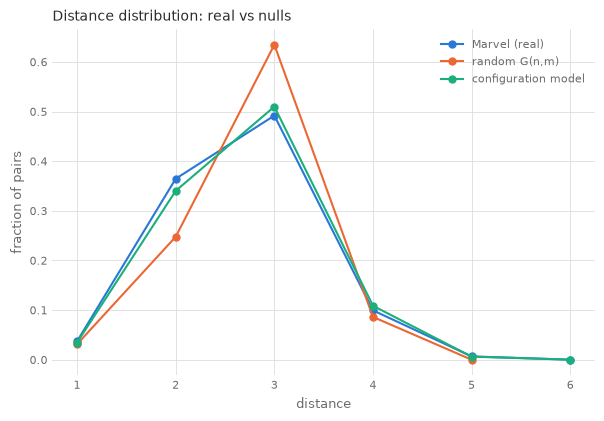

In [33]:
dist_counts = {}
for node in tracked("distance distribution (real)", giant_n):
    src = list(Ug.nodes())[node]
    for d in bfs_hand(Ug, src).values():
        if d > 0:
            dist_counts[d] = dist_counts.get(d, 0) + 1
total_pairs = giant_n * (giant_n - 1)
dist_dist_real = {d: c / total_pairs for d, c in dist_counts.items()}

def distance_distribution(g):
    n = g.number_of_nodes()
    counts = {}
    for src in g.nodes():
        for d in nx.single_source_shortest_path_length(g, src).values():
            if d > 0:
                counts[d] = counts.get(d, 0) + 1
    tot = n * (n - 1)
    return {d: c / tot for d, c in counts.items()}

dist_dist_rand = distance_distribution(G_marvel_rand.subgraph(rand_giant_nodes))
config_for_dist = simple_configuration(deg_seq, SEED)
config_giant = config_for_dist.subgraph(max(nx.connected_components(config_for_dist), key=len)).copy()
dist_dist_config = distance_distribution(config_giant)

print(f"{'d':>3}{'real':>10}{'G(n,m)':>10}{'config':>10}")
for d in range(1, 7):
    print(f"{d:>3}{dist_dist_real.get(d, 0.0):>10.3f}{dist_dist_rand.get(d, 0.0):>10.3f}{dist_dist_config.get(d, 0.0):>10.3f}")

fig, ax = plt.subplots(figsize=(7, 4.5))
for label, dd, colour in [("Marvel (real)", dist_dist_real, BLUE),
                           ("random G(n,m)", dist_dist_rand, ORANGE),
                           ("configuration model", dist_dist_config, GREEN)]:
    xs = sorted(dd)
    ax.plot(xs, [dd[x] for x in xs], "-o", color=colour, markersize=5, label=label)
style(ax, "distance", "fraction of pairs")
ax.set_title("Distance distribution: real vs nulls", fontsize=10, color=INK, loc="left")
ax.legend(frameon=False, fontsize=8, labelcolor=MUTED)
plt.show()

The table above shows which null reproduces the shape. The real network puts 0.365 of pairs at distance
2 and 0.492 at distance 3. The configuration model, which keeps the real degree sequence, is close on
both counts (0.340 and 0.510). The density-only random network shifts weight away from distance 2 down
to 0.248 and piles more onto distance 3 (0.635): fewer hubs to shortcut through at 2 hops, so more pairs
need a third hop. Keeping the degree sequence, not just the edge count, is what reproduces Marvel's
distance distribution.

In [34]:
scc_nodes = max(nx.strongly_connected_components(D), key=len)
print(f"largest SCC size: {len(scc_nodes)}   brief: 229")
assert len(scc_nodes) == 229

reachable_pairs = 0
total_directed_dists = []
sample_nodes = list(D.nodes())
for node in tracked("directed reachability", len(sample_nodes)):
    src = sample_nodes[node]
    lengths = nx.single_source_shortest_path_length(D, src)
    reachable_pairs += len(lengths) - 1
    total_directed_dists.extend(d for target, d in lengths.items() if target != src)

frac_reachable = reachable_pairs / (N * (N - 1))
mean_directed_d = np.mean(total_directed_dists)
print(f"fraction of ordered pairs reachable: {frac_reachable:.3f}")
print(f"mean directed distance (over reachable pairs): {mean_directed_d:.3f}")

largest SCC size: 229   brief: 229
directed reachability: 30/303 (10%), 0s elapsed, about 0s left


directed reachability: 60/303 (20%), 0s elapsed, about 0s left


directed reachability: 90/303 (30%), 0s elapsed, about 0s left


directed reachability: 120/303 (40%), 0s elapsed, about 0s left


directed reachability: 150/303 (50%), 0s elapsed, about 0s left


...

directed reachability: 240/303 (79%), 0s elapsed, about 0s left


directed reachability: 270/303 (89%), 0s elapsed, about 0s left


directed reachability: 300/303 (99%), 0s elapsed, about 0s left


directed reachability: 303/303 (100%), 0s elapsed, about 0s left


fraction of ordered pairs reachable: 0.690
mean directed distance (over reachable pairs): 3.427


In [35]:
# find A, B with d(A,B) = 1 and d(B,A) >= 5
found = None
for a, b in D.edges():
    try:
        dba = nx.shortest_path_length(D, b, a)
    except nx.NetworkXNoPath:
        continue
    if dba >= 5:
        found = (a, b, dba)
        break

a, b, dba = found
b_outlinks = [name[x] for x in D.successors(b)]
print(f"{name[a]} -> {name[b]}: d = 1")
print(f"{name[b]} -> {name[a]}: d = {dba}")
print(f"{name[b]}'s out-links ({len(b_outlinks)}): {b_outlinks}")
print()
print(f"Explanation from the network alone: {name[b]}'s page links out to only "
      f"{len(b_outlinks)} other characters, none of which sit near {name[a]} in the link graph, "
      f"so the walk back has to detour through the rest of the network. We cannot read "
      f"{name[b]}'s live Wikipedia article to confirm the editorial reason; this is the limit of "
      f"what the frozen snapshot can explain.")

Ajak -> Makkari (character): d = 1
Makkari (character) -> Ajak: d = 5
Makkari (character)'s out-links (1): ['Quasar (character)']

Explanation from the network alone: Makkari (character)'s page links out to only 1 other characters, none of which sit near Ajak in the link graph, so the walk back has to detour through the rest of the network. We cannot read Makkari (character)'s live Wikipedia article to confirm the editorial reason; this is the limit of what the frozen snapshot can explain.


## 3.5: Centralities on Marvel

Degree, closeness, harmonic, and betweenness on the undirected giant: top tens, overlap, betweenness
vs degree with outliers named, then betweenness recomputed with the arrows kept.

In [36]:
deg_c = dict(Ug.degree())
close_c = nx.closeness_centrality(Ug)
harm_c = nx.harmonic_centrality(Ug)
between_c = nx.betweenness_centrality(Ug, normalized=True)

def top10(d):
    return [name[n] for n, _ in sorted(d.items(), key=lambda kv: -kv[1])[:10]]

tops = {"degree": top10(deg_c), "closeness": top10(close_c),
        "harmonic": top10(harm_c), "betweenness": top10(between_c)}
for k, v in tops.items():
    print(f"{k:>12}: {v}")

in_all_four = set(tops["degree"]) & set(tops["closeness"]) & set(tops["harmonic"]) & set(tops["betweenness"])
print()
print(f"in all four top tens ({len(in_all_four)}): {sorted(in_all_four)}")

      degree: ['Spider-Man', 'Hulk', 'Wolverine (character)', 'Doctor Strange', 'Deadpool', 'She-Hulk', 'Phoenix (Guardians of the Galaxy)', 'Scarlet Witch', 'Black Panther (character)', 'Venom (character)']
   closeness: ['Spider-Man', 'Hulk', 'Wolverine (character)', 'Doctor Strange', 'Deadpool', 'She-Hulk', 'Scarlet Witch', 'Phoenix (Guardians of the Galaxy)', 'Moon Knight', 'Adam Warlock']
    harmonic: ['Spider-Man', 'Hulk', 'Wolverine (character)', 'Doctor Strange', 'Deadpool', 'She-Hulk', 'Scarlet Witch', 'Phoenix (Guardians of the Galaxy)', 'Moon Knight', 'Cloak and Dagger (characters)']
 betweenness: ['Spider-Man', 'Hulk', 'Wolverine (character)', 'Doctor Strange', 'Deadpool', 'She-Hulk', 'Hercules (Marvel Comics)', 'Black Widow (Natasha Romanova)', 'Phoenix (Guardians of the Galaxy)', 'U.S. Agent']

in all four top tens (7): ['Deadpool', 'Doctor Strange', 'Hulk', 'Phoenix (Guardians of the Galaxy)', 'She-Hulk', 'Spider-Man', 'Wolverine (character)']


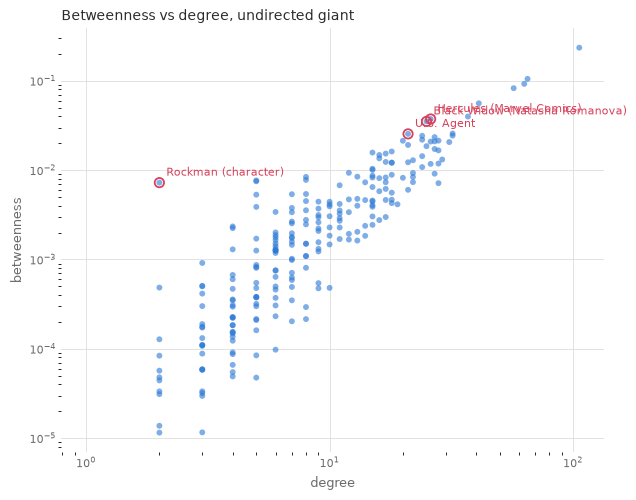

In [37]:
degs_arr = np.array([deg_c[n] for n in Ug.nodes()])
betw_arr = np.array([between_c[n] for n in Ug.nodes()])
names_arr = [name[n] for n in Ug.nodes()]

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(degs_arr, betw_arr, s=18, color=BLUE, alpha=0.6, edgecolors="none")
ax.set_xscale("log"); ax.set_yscale("log")
style(ax, "degree", "betweenness")
ax.set_title("Betweenness vs degree, undirected giant", fontsize=10, color=INK, loc="left")

for label in ["Hercules (Marvel Comics)", "Black Widow (Natasha Romanova)", "U.S. Agent", "Rockman (character)"]:
    node = next((nd for nd, nm in name.items() if nm == label and nd in Ug), None)
    if node is None:
        continue
    ax.annotate(label, (deg_c[node], between_c[node]), fontsize=8, color=RED,
                xytext=(5, 5), textcoords="offset points")
    ax.scatter([deg_c[node]], [between_c[node]], s=45, facecolors="none", edgecolors=RED, linewidths=1.3)
plt.show()

In [38]:
for label in ["Hercules (Marvel Comics)", "Black Widow (Natasha Romanova)", "U.S. Agent"]:
    node = next((nd for nd, nm in name.items() if nm == label), None)
    if node is None or node not in Ug:
        continue
    rank_deg = sorted(deg_c, key=lambda n: -deg_c[n]).index(node) + 1
    rank_bet = sorted(between_c, key=lambda n: -between_c[n]).index(node) + 1
    neighbors = [name[x] for x in Ug.neighbors(node)]
    print(f"{label}: degree {deg_c[node]} (rank {rank_deg}), betweenness rank {rank_bet}")
    print(f"  neighbors: {neighbors}")
    print()

Hercules (Marvel Comics): degree 26 (rank 20), betweenness rank 7
  neighbors: ['Abomination (character)', 'Ajak', 'Ares (Marvel Comics)', 'Balder the Brave', 'Bill Foster (character)', 'Black Widow (Natasha Romanova)', 'Cable (character)', 'Captain Marvel (Marvel Comics)', 'Dargo Ktor', 'Firelord (character)', 'Flatman (character)', 'Hulk', 'Human Torch', 'Living Lightning', 'Noh-Varr', 'Quicksilver (Marvel Comics)', 'Red Guardian', 'Red Wolf (comics)', 'She-Hulk', 'Spider-Man', 'Star-Lord', 'Kismet (Marvel Comics)', 'Northstar (character)', 'Raza Longknife', 'Rocket Raccoon', 'Wolverine (character)']

Black Widow (Natasha Romanova): degree 25 (rank 23), betweenness rank 8
  neighbors: ['Adam Warlock', 'Ghost Rider (Johnny Blaze)', 'Hercules (Marvel Comics)', 'Red Guardian', 'Spider-Man', 'Venom (character)', 'Wolverine (character)', 'Yelena Belova', 'Blue Eagle (character)', 'Cloak and Dagger (characters)', 'Deadpool', 'Doctor Strange', 'Eddie Brock', 'Firebird (Marvel Comics)', 'Haw

Hercules and Black Widow both bridge distinct corners of the universe (the Avengers on one side and
smaller casts, cosmic or espionage characters, on the other), so paths between those corners are forced
through them even though many other characters have more links. Their betweenness rank sits well above
their degree rank, the Krackhardt signature: a broker's value comes from position, not popularity.

In [39]:
rockman = next((nd for nd, nm in name.items() if nm == "Rockman (character)"), None)
if rockman is not None and rockman in Ug:
    rockman_neighbors = list(Ug.neighbors(rockman))
    print(f"Rockman: degree {deg_c[rockman]}, betweenness {between_c[rockman]:.4f}")
    print(f"Rockman's direct neighbors: {[name[x] for x in rockman_neighbors]}")
    for nb in rockman_neighbors:
        print(f"  {name[nb]}: degree {deg_c[nb]}, neighbors {[name[x] for x in Ug.neighbors(nb)]}")
else:
    print("Rockman not found in the giant component of this snapshot")

Rockman: degree 2, betweenness 0.0072
Rockman's direct neighbors: ['Black Widow (Natasha Romanova)', 'The Witness (character)']
  Black Widow (Natasha Romanova): degree 25, neighbors ['Adam Warlock', 'Ghost Rider (Johnny Blaze)', 'Hercules (Marvel Comics)', 'Red Guardian', 'Spider-Man', 'Venom (character)', 'Wolverine (character)', 'Yelena Belova', 'Blue Eagle (character)', 'Cloak and Dagger (characters)', 'Deadpool', 'Doctor Strange', 'Eddie Brock', 'Firebird (Marvel Comics)', 'Hawkeye (comics)', 'Human Torch (android)', 'Iron Man (Ultimate Marvel character)', 'Janice Lincoln', 'Mockingbird (Marvel Comics)', 'Rockman (character)', 'Shuri (character)', 'Spider-Man Noir', 'Spider-Woman', 'Spider-Woman (Jessica Drew)', 'Ursa Major (character)']
  The Witness (character): degree 1, neighbors ['Rockman (character)']


Black Widow is a hub with many other routes into the network, so she is not the reason for Rockman's
betweenness. His other neighbor, The Witness, has degree 1: Rockman is its only link to the rest of the
giant component, printed above. Every shortest path between The Witness and anyone else in the network
has to cross Rockman's two links, which is why a degree-2 node scores far above other degree-2
characters: he is the sole bridge to a dead end, not a hub with alternatives.

In [40]:
between_directed = nx.betweenness_centrality(D, normalized=True)
between_undirected_on_D_nodes = {n: between_c.get(n, 0.0) for n in D.nodes()}

movers = []
for n in D.nodes():
    if n in between_c:
        movers.append((name[n], between_undirected_on_D_nodes[n], between_directed[n]))
movers.sort(key=lambda t: t[2] - t[1], reverse=True)
print("largest increases, undirected -> directed betweenness:")
for nm, u, d in movers[:8]:
    print(f"  {nm:<25} undirected {u:.4f}  ->  directed {d:.4f}")

largest increases, undirected -> directed betweenness:
  Hercules (Marvel Comics)  undirected 0.0374  ->  directed 0.0610
  Paladin (comics)          undirected 0.0016  ->  directed 0.0194
  Venom (character)         undirected 0.0132  ->  directed 0.0292
  Cloak and Dagger (characters) undirected 0.0214  ->  directed 0.0364
  Robbie Baldwin            undirected 0.0065  ->  directed 0.0206
  Black Cat (Marvel Comics) undirected 0.0071  ->  directed 0.0207
  Iron Fist (character)     undirected 0.0209  ->  directed 0.0334
  Jean Grey                 undirected 0.0108  ->  directed 0.0230


Hercules moves up because the directed graph removes some of the alternate routes his undirected
betweenness could share credit with: a shortest path that only exists one way (A links to B but not
back) has fewer competing paths through other characters, so a broker on real one-way links carries
more of the total betweenness once direction is respected.

## 3.7: PageRank on Marvel

PageRank at $\alpha=0.85$ on the directed network vs the in-degree top ten, checking for Black Cat and
Mayday Parker; hand-written power iteration validated against `nx.pagerank` to six decimals for three
values of $\alpha$; dangling nodes explained.

In [41]:
pr = nx.pagerank(D, alpha=0.85)
top_pr = top10(pr)
top_indeg = top10(dict(D.in_degree()))
print("PageRank top 10:  ", top_pr)
print("in-degree top 10: ", top_indeg)
only_pr = [x for x in top_pr if x not in top_indeg]
only_indeg = [x for x in top_indeg if x not in top_pr]
print(f"in PageRank only: {only_pr}")
print(f"in in-degree only: {only_indeg}")

PageRank top 10:  

 ['Spider-Man', 'Hulk', 'Wolverine (character)', 'Doctor Strange', 'Black Cat (Marvel Comics)', 'Deadpool', 'Mayday Parker', 'Venom (character)', 'Phoenix (Guardians of the Galaxy)', 'Jean Grey']
in-degree top 10:  ['Spider-Man', 'Hulk', 'Wolverine (character)', 'Doctor Strange', 'Deadpool', 'She-Hulk', 'Scarlet Witch', 'Black Panther (character)', 'Cyclops (Marvel Comics)', 'Luke Cage']
in PageRank only: ['Black Cat (Marvel Comics)', 'Mayday Parker', 'Venom (character)', 'Phoenix (Guardians of the Galaxy)', 'Jean Grey']
in in-degree only: ['She-Hulk', 'Scarlet Witch', 'Black Panther (character)', 'Cyclops (Marvel Comics)', 'Luke Cage']


In [42]:
for label in ["Black Cat (Marvel Comics)", "Mayday Parker"]:
    node = next((nd for nd, nm in name.items() if nm == label), None)
    if node is None:
        continue
    rank_pr = top10(pr).index(label) + 1 if label in top_pr else None
    givers = [name[x] for x in D.predecessors(node)]
    print(f"{label}: in-degree {D.in_degree(node)}, PageRank rank {rank_pr}")
    print(f"  linked from: {givers}")

Black Cat (Marvel Comics): in-degree 21, PageRank rank 5
  linked from: ['Betsy Braddock', 'Cloak and Dagger (characters)', 'Eddie Brock', 'Gwenpool', 'Jericho Drumm', 'Mania (character)', 'Mayday Parker', 'Misty Knight', 'Morbius', 'Patsy Walker', 'Satana (Marvel Comics)', 'Scarlet Spider', 'Silk (character)', 'Spider-Girl', 'Spider-Man', 'Spider-Man (Marvel Mangaverse)', 'Spider-Man Noir', 'Spider-Woman (Gwen Stacy)', 'Storm (Marvel Comics)', 'Tarantula (Marvel Comics)', 'Venom (character)']
Mayday Parker: in-degree 14, PageRank rank 7
  linked from: ['Anya Corazon', 'Black Cat (Marvel Comics)', 'Darkdevil', 'Nova (Richard Rider)', 'Phil Urich', 'Scarlet Spider', 'Spider-Bitch (Ashley Barton)', 'Spider-Girl', 'Spider-Man', 'Spider-UK', 'Spider-Woman', 'Spider-Woman (Gwen Stacy)', 'Steel Spider', 'Venom (character)']


In [43]:
def pagerank_power_iteration(g, alpha, max_iter=1000, tol=1e-14):
    """Hand-written PageRank: power iteration on the walk matrix, dangling nodes
    redistributed uniformly (same convention as networkx.pagerank)."""
    nodes = list(g.nodes())
    idx = {node: i for i, node in enumerate(nodes)}
    n = len(nodes)
    outdeg = dict(g.out_degree())
    dangling = [idx[node] for node in nodes if outdeg[node] == 0]

    pr_vec = np.full(n, 1.0 / n)
    for _ in range(max_iter):
        new = np.zeros(n)
        dangling_mass = pr_vec[dangling].sum()
        for u in nodes:
            if outdeg[u] == 0:
                continue
            share = pr_vec[idx[u]] / outdeg[u]
            for v in g.successors(u):
                new[idx[v]] += share
        new = alpha * (new + dangling_mass / n) + (1 - alpha) / n
        if np.abs(new - pr_vec).sum() < tol:
            pr_vec = new
            break
        pr_vec = new
    return dict(zip(nodes, pr_vec))

for alpha_test in [0.5, 0.85, 0.95]:
    hand = pagerank_power_iteration(D, alpha_test)
    lib = nx.pagerank(D, alpha=alpha_test, tol=1e-12, max_iter=1000)
    max_diff = max(abs(hand[n] - lib[n]) for n in D.nodes())
    print(f"alpha={alpha_test}: max |hand - nx.pagerank| = {max_diff:.2e}   matches to 6dp: {max_diff < 5e-7}")
    assert max_diff < 5e-7

alpha=0.5: max |hand - nx.pagerank| = 1.42e-11   matches to 6dp: True
alpha=0.85: max |hand - nx.pagerank| = 1.23e-10   matches to 6dp: True


alpha=0.95: max |hand - nx.pagerank| = 4.39e-10   matches to 6dp: True


Dangling nodes (out-degree 0, which includes every isolate and every character whose page links to
nobody in the snapshot) have nowhere to send their PageRank mass forward. The hand-written iteration
handles this the way `nx.pagerank` does: at each step, the total mass sitting on dangling nodes is
collected and redistributed uniformly over every node, the same way the teleportation term works, rather than
being lost or left stuck. Skipping this step would leak probability mass out of the walk each round and
the vector would no longer sum to 1.

## 3.8: Brokers, compared to what

200 degree-preserving shuffles of the undirected giant, z-score of each character's real betweenness
and closeness against its own shuffled distribution, plotted against degree.

In [44]:
DRAWS_SHUFFLE_BC = 200
nodes_giant = list(Ug.nodes())
betw_samples = {n: [] for n in nodes_giant}
close_samples = {n: [] for n in nodes_giant}

for i in tracked("betweenness/closeness shuffles", DRAWS_SHUFFLE_BC):
    gs = degree_preserving_shuffle(Ug, 10, SEED + i)
    bs = nx.betweenness_centrality(gs, normalized=True)
    cs = nx.closeness_centrality(gs)
    for n in nodes_giant:
        betw_samples[n].append(bs.get(n, 0.0))
        close_samples[n].append(cs.get(n, 0.0))

betw_z, close_z = {}, {}
for n in nodes_giant:
    bmean, bsd = np.mean(betw_samples[n]), np.std(betw_samples[n])
    cmean, csd = np.mean(close_samples[n]), np.std(close_samples[n])
    betw_z[n] = (between_c[n] - bmean) / bsd if bsd > 0 else 0.0
    close_z[n] = (close_c[n] - cmean) / csd if csd > 0 else 0.0

hercules_node = next(nd for nd, nm in name.items() if nm == "Hercules (Marvel Comics)")
print(f"Hercules: betweenness {between_c[hercules_node]:.4f}, "
      f"shuffled mean {np.mean(betw_samples[hercules_node]):.4f}, z = {betw_z[hercules_node]:.2f}   brief: ~4 sd")

top_betw_z = sorted(nodes_giant, key=lambda n: -betw_z[n])[:5]
print("top 5 by betweenness z-score:", [(name[n], round(betw_z[n], 2)) for n in top_betw_z])

top_close_z = sorted(nodes_giant, key=lambda n: -abs(close_z[n]))[:5]
print("top 5 by |closeness z-score|:", [(name[n], round(close_z[n], 2)) for n in top_close_z])

mean_abs_betw_z = np.mean([abs(betw_z[n]) for n in nodes_giant])
mean_abs_close_z = np.mean([abs(close_z[n]) for n in nodes_giant])
print(f"mean |z|: betweenness {mean_abs_betw_z:.2f}   closeness {mean_abs_close_z:.2f}")

betweenness/closeness shuffles: 20/200 (10%), 3s elapsed, about 32s left


betweenness/closeness shuffles: 40/200 (20%), 7s elapsed, about 31s left


betweenness/closeness shuffles: 60/200 (30%), 12s elapsed, about 29s left


betweenness/closeness shuffles: 80/200 (40%), 17s elapsed, about 26s left


betweenness/closeness shuffles: 100/200 (50%), 21s elapsed, about 21s left


...

betweenness/closeness shuffles: 140/200 (70%), 28s elapsed, about 12s left


betweenness/closeness shuffles: 160/200 (80%), 32s elapsed, about 8s left


betweenness/closeness shuffles: 180/200 (90%), 37s elapsed, about 4s left


betweenness/closeness shuffles: 200/200 (100%), 40s elapsed, about 0s left


Hercules: betweenness 0.0374, shuffled mean 0.0176, z = 3.82   brief: ~4 sd
top 5 by betweenness z-score: [('Rockman (character)', np.float64(8.76)), ('Nightmask', np.float64(4.65)), ('Black Widow (Natasha Romanova)', np.float64(4.15)), ('Turbo (comics)', np.float64(4.0)), ('Ikaris', np.float64(3.95))]
top 5 by |closeness z-score|: [('Cyclops (Marvel Comics)', np.float64(-5.02)), ('Quasar (character)', np.float64(-4.28)), ('Human Torch (android)', np.float64(-3.78)), ('Bucky (Marvel Comics)', np.float64(-3.5)), ('Jeffrey Mace', np.float64(-3.49))]
mean |z|: betweenness 0.72   closeness 1.12


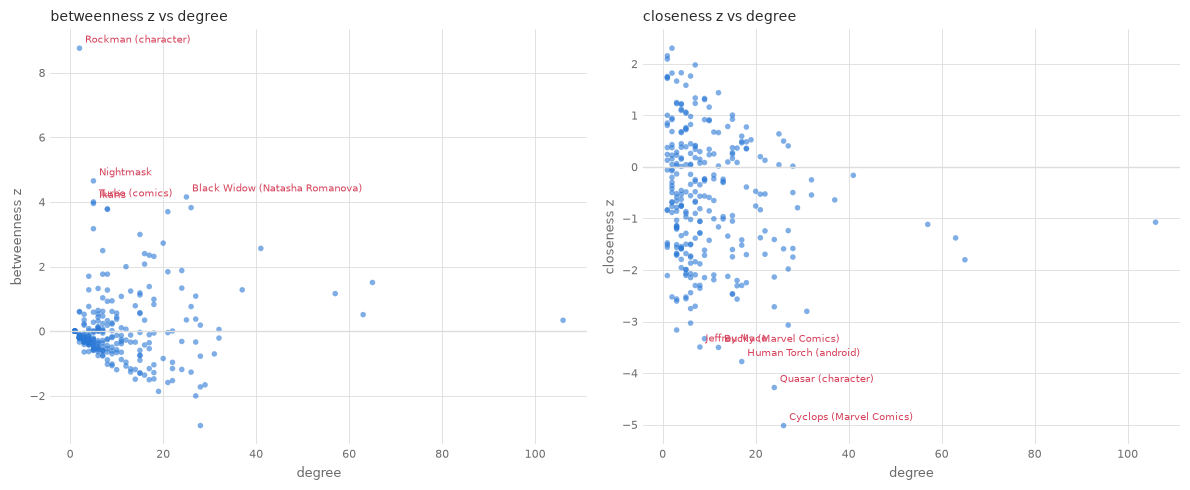

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, zdict, title in zip(axes, [betw_z, close_z], ["betweenness z", "closeness z"]):
    xs = [deg_c[n] for n in nodes_giant]
    ys = [zdict[n] for n in nodes_giant]
    ax.scatter(xs, ys, s=16, color=BLUE, alpha=0.6, edgecolors="none")
    ax.axhline(0, color=GRID, linewidth=1)
    style(ax, "degree", title)
    ax.set_title(f"{title} vs degree", fontsize=10, color=INK, loc="left")

    surprises = sorted(nodes_giant, key=lambda n: -abs(zdict[n]))[:5]
    for n in surprises:
        ax.annotate(name[n], (deg_c[n], zdict[n]), fontsize=7, color=RED,
                    xytext=(4, 4), textcoords="offset points")
plt.tight_layout(); plt.show()

Black Widow lands in the top five betweenness z-scores (4.15), and Hercules sits close behind at 3.82
(printed above), both in the direction of "more of a broker than degree predicts," matching this page's
names. The largest surprise is Rockman at 8.76: the degree-2 bottleneck from 3.5, whose two links are
the only door between The Witness and the rest of the network, a position a degree-preserving shuffle
does not reproduce by chance.

Closeness surprises in the other direction: its top five z-scores (printed above) are all negative,
led by Cyclops at -5.02, meaning these characters sit farther from everyone than a same-degree node
typically does once the network is scrambled. Closeness's mean |z| (1.12) is higher than betweenness's
(0.72), so on average a character's closeness moves further from its shuffled distribution than its
betweenness does, even though betweenness produces the single largest surprises (Rockman's 8.76 dwarfs
Cyclops's -5.02). The two centralities are surprised by different things, and neither summary alone
tells the whole story.

**Hercules, correctly stated:** Hercules's betweenness is 0.037 on the real network, against a
degree-preserving shuffle's mean of 0.018 and a z-score of 3.8. That places him standard deviations
above what his degree alone predicts, so his position in the network is doing work his popularity does
not explain. It does not mean he is the most important character overall, only that removing him would
force more rerouting between the parts of the universe he connects than his degree would suggest.

## 3.9: Mixing, compared to what

Degree assortativity $r$ on the undirected giant, $k_{nn}(k)$ on log axes, a 200-shuffle z-score;
directed out-in and in-out assortativity.

In [46]:
r_giant = nx.degree_assortativity_coefficient(Ug)
print(f"r (undirected giant) = {r_giant:.3f}   brief: -0.105")

r (undirected giant) = -0.105   brief: -0.105


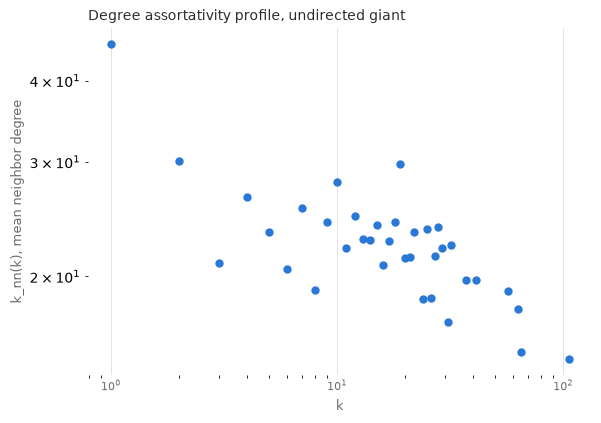

In [47]:
knn = nx.average_neighbor_degree(Ug)
deg_to_knn = {}
for n in nodes_giant:
    deg_to_knn.setdefault(deg_c[n], []).append(knn[n])
ks_sorted = sorted(deg_to_knn)
knn_mean = [np.mean(deg_to_knn[k]) for k in ks_sorted]

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.scatter(ks_sorted, knn_mean, s=25, color=BLUE)
ax.set_xscale("log"); ax.set_yscale("log")
style(ax, "k", "k_nn(k), mean neighbor degree")
ax.set_title("Degree assortativity profile, undirected giant", fontsize=10, color=INK, loc="left")
plt.show()

In [48]:
DRAWS_ASSORT = 200
r_samples = []
for i in tracked("assortativity shuffles", DRAWS_ASSORT):
    gs = degree_preserving_shuffle(Ug, 10, SEED + 1000 + i)
    r_samples.append(nx.degree_assortativity_coefficient(gs))

r_samples = np.array(r_samples)
z_r = (r_giant - r_samples.mean()) / r_samples.std()
print(f"shuffled r: {r_samples.mean():.3f} +/- {r_samples.std():.3f}   brief: -0.118 +/- 0.009")
print(f"z = {z_r:.2f}")

assortativity shuffles: 20/200 (10%), 1s elapsed, about 11s left


assortativity shuffles: 40/200 (20%), 2s elapsed, about 10s left


assortativity shuffles: 60/200 (30%), 3s elapsed, about 8s left


assortativity shuffles: 80/200 (40%), 4s elapsed, about 7s left


assortativity shuffles: 100/200 (50%), 6s elapsed, about 6s left


...

assortativity shuffles: 140/200 (70%), 8s elapsed, about 3s left


assortativity shuffles: 160/200 (80%), 10s elapsed, about 2s left


assortativity shuffles: 180/200 (90%), 11s elapsed, about 1s left


assortativity shuffles: 200/200 (100%), 12s elapsed, about 0s left


shuffled r: -0.122 +/- 0.010   brief: -0.118 +/- 0.009
z = 1.64


Marvel's degree assortativity, -0.105, sits about 1.6 standard deviations from the degree-preserving
shuffle's mean (z printed above), so the mild disassortativity is what its degree sequence forces (a 106-link hub in a
277-node giant has too few other hubs to link to), not a Marvel-specific mixing pattern.

In [49]:
# x is the source node's degree type, y is the target's (networkx convention)
r_out_in = nx.degree_assortativity_coefficient(D, x="out", y="in")     # source out-degree vs target in-degree
r_in_out = nx.degree_assortativity_coefficient(D, x="in", y="out")     # source in-degree vs target out-degree
print(f"source out-degree vs target in-degree: {r_out_in:.3f}")
print(f"source in-degree vs target out-degree: {r_in_out:.3f}")

source out-degree vs target in-degree: -0.023
source in-degree vs target out-degree: 0.100


Source out-degree against target in-degree sits near zero: a page's own out-degree says little about how
famous the pages it links to are. Source in-degree against target out-degree is positive: a page that is
already linked to a lot (high in-degree) tends to link out to pages that themselves link out a lot (high
out-degree). Already-famous characters point to characters whose pages mention many others, rather than
to characters with short, narrow pages.

**Homophily sub-item, skipped.** Testing homophily by team (X-Men, Avengers, ...) needs a categorical
label per character, and the only text available offline is the free-form `description` column in
`week1_nodes.tsv`, which is not a clean, consistently-populated category (some describe teams, some
describe powers, some are empty). Building that label would mean hand-typing it from outside knowledge,
which the spec rules out; the exercise needs a live Wikipedia/Wikidata fetch this notebook does not do.

## Cliques (week 3, Part 8)

Triangles, 5-cliques, and the clique number, checked against the brief's numbers.

In [50]:
n_triangles = sum(nx.triangles(Ug).values()) // 3
cliques = list(nx.find_cliques(Ug))                      # maximal cliques
n_5cliques = sum(1 for c in nx.enumerate_all_cliques(Ug) if len(c) == 5)   # every 5-clique, not just maximal
clique_number = max(len(c) for c in cliques)
eights = [set(name[n] for n in c) for c in cliques if len(c) == clique_number]

print(f"triangles     {n_triangles}   brief: 1,835")
print(f"5-cliques     {n_5cliques}   brief: 477")
print(f"clique number {clique_number}   brief: 8")
print(f"number of distinct maximal 8-cliques: {len(eights)}")
for e in sorted(sorted(x) for x in eights):   # set order differs between processes
    print(f"  {e}")

assert n_triangles == 1835
assert n_5cliques == 477
assert clique_number == 8

expected_eight = {"Betsy Braddock", "Cable (character)", "Cyclops (Marvel Comics)", "Emma Frost",
                  "Jean Grey", "Northstar (character)", "Rachel Summers", "Wolverine (character)"}
assert expected_eight in eights
core_six = set.intersection(*eights)
print()
print(f"the brief's eight (with Cable and Northstar) is one of {len(eights)} maximal 8-cliques found")
print(f"the six members every one of them shares: {sorted(core_six)}")

triangles     1835   brief: 1,835
5-cliques     477   brief: 477
clique number 8   brief: 8
number of distinct maximal 8-cliques: 6
  ['Betsy Braddock', 'Cable (character)', 'Cyclops (Marvel Comics)', 'Emma Frost', 'Jean Grey', 'Jubilee (character)', 'Rachel Summers', 'Wolverine (character)']
  ['Betsy Braddock', 'Cable (character)', 'Cyclops (Marvel Comics)', 'Emma Frost', 'Jean Grey', 'Northstar (character)', 'Rachel Summers', 'Wolverine (character)']
  ['Betsy Braddock', 'Cable (character)', 'Cyclops (Marvel Comics)', 'Emma Frost', 'Jean Grey', 'Phoenix (Guardians of the Galaxy)', 'Rachel Summers', 'Wolverine (character)']
  ['Betsy Braddock', 'Cyclops (Marvel Comics)', 'Emma Frost', 'Jean Grey', 'Jubilee (character)', 'Rachel Summers', 'Storm (Marvel Comics)', 'Wolverine (character)']
  ['Betsy Braddock', 'Cyclops (Marvel Comics)', 'Emma Frost', 'Jean Grey', 'Northstar (character)', 'Rachel Summers', 'Storm (Marvel Comics)', 'Wolverine (character)']
  ['Betsy Braddock', 'Cyclops (M

## 4.5: Louvain on Marvel, as code

Run on the undirected giant instead of the philosophers (both are course networks; Marvel needs no
philosophy-specific data for community detection). Communities, $Q$, named by top members, stability
across five seeds via a 5x5 NMI matrix, then `greedy_modularity_communities` for comparison. Finally
a hand-written Louvain phase 1, validated against `nx.community.modularity` on the karate club.

In [51]:
louvain_parts, Q_louvain = igraph_louvain(Ug, seed=SEED)
print(f"Louvain: {len(louvain_parts)} communities, Q = {Q_louvain:.3f}")

for i, comm in enumerate(sorted(louvain_parts, key=len, reverse=True)):
    top5 = sorted(comm, key=lambda n: (-deg_c[n], name[n]))[:5]   # name as tiebreak: deterministic across runs
    print(f"community {i} (n={len(comm)}): {[name[n] for n in top5]}")

Louvain: 8 communities, Q = 0.387
community 0 (n=51): ['Black Panther (character)', 'Luke Cage', 'Hank Pym', 'Moon Knight', 'Iron Fist (character)']
community 1 (n=44): ['Wolverine (character)', 'Phoenix (Guardians of the Galaxy)', 'Betsy Braddock', 'Emma Frost', 'Storm (Marvel Comics)']
community 2 (n=40): ['Hercules (Marvel Comics)', 'Adam Warlock', 'Quasar (character)', 'Nova (Richard Rider)', 'Noh-Varr']
community 3 (n=39): ['Spider-Man', 'Venom (character)', 'Black Cat (Marvel Comics)', 'Eddie Brock', 'Spider-Woman (Jessica Drew)']
community 4 (n=34): ['Doctor Strange', 'Deadpool', 'Blade (character)', 'Ghost Rider', 'Man-Thing']
community 5 (n=30): ['Scarlet Witch', 'Black Bolt', 'Human Torch', 'Human Torch (android)', 'Quicksilver (Marvel Comics)']
community 6 (n=29): ['Hulk', 'She-Hulk', 'Solo (Marvel Comics)', 'Brian Braddock', 'Vance Astrovik']
community 7 (n=10): ['Cloak and Dagger (characters)', 'Deathlok', 'Darkhawk', 'Chase Stein', 'Cammi (character)']


Naming each community from its five highest-degree members, most read as a recognizable corner of the
universe: community 1 (Wolverine, Phoenix, Betsy Braddock, Storm, Emma Frost) is the X-Men; community 3
(Spider-Man, Venom, Black Cat, Eddie Brock, Spider-Woman) is the Spider-Man family; community 6 (Hulk,
She-Hulk, Solo, Brian Braddock, Vance Astrovik) is the Hulk/young-Avengers cluster; community 4 (Doctor
Strange, Deadpool, Blade, Ghost Rider, Man-Thing) is the supernatural/horror side of the universe;
community 2 (Hercules, Adam Warlock, Quasar, Nova, Noh-Varr) reads as the cosmic characters; community 5
(Scarlet Witch, Black Bolt, Human Torch, Human Torch (android), Quicksilver) reads loosely as Inhumans and
their Avengers-adjacent allies. Two communities resist a clean name: community 0 (Black Panther, Luke
Cage, Hank Pym, Moon Knight, Iron Fist) mixes street-level heroes with founding Avengers, and community 7
(Cloak and Dagger, Deathlok, Darkhawk, Chase Stein, Cammi) has no shared team or era among its top five.
Louvain grouped both by link structure, and their labels have to be looser than the crisper teams above.

In [52]:
SEEDS_5 = [SEED + i for i in range(5)]
runs = []
for i in tracked("Louvain, 5 seeds", len(SEEDS_5)):
    parts, q = igraph_louvain(Ug, seed=SEEDS_5[i])
    labels_i = {n: c for c, comm in enumerate(parts) for n in comm}
    runs.append((len(parts), q, [labels_i[n] for n in nodes_giant]))
    print(f"seed {SEEDS_5[i]}: {len(parts)} communities, Q = {q:.3f}")

nmi_matrix = np.zeros((5, 5))
for i in range(5):
    for j in range(5):
        nmi_matrix[i, j] = nmi(runs[i][2], runs[j][2])

print()
print("5x5 NMI matrix:")
print(pd.DataFrame(nmi_matrix, index=[f"seed{i}" for i in range(5)], columns=[f"seed{i}" for i in range(5)]).round(3))

off_diag = nmi_matrix[~np.eye(5, dtype=bool)]
print(f"lowest pairwise NMI: {off_diag.min():.3f}   brief: two Marvel runs agree at NMI 0.59")

seed 2805: 8 communities, Q = 0.387
Louvain, 5 seeds: 1/5 (20%), 0s elapsed, about 0s left


seed 2806: 7 communities, Q = 0.382
Louvain, 5 seeds: 2/5 (40%), 0s elapsed, about 0s left


seed 2807: 8 communities, Q = 0.382
Louvain, 5 seeds: 3/5 (60%), 0s elapsed, about 0s left


seed 2808: 8 communities, Q = 0.386
Louvain, 5 seeds: 4/5 (80%), 0s elapsed, about 0s left


seed 2809: 8 communities, Q = 0.381
Louvain, 5 seeds: 5/5 (100%), 0s elapsed, about 0s left



5x5 NMI matrix:
       seed0  seed1  seed2  seed3  seed4
seed0  1.000  0.694  0.746  0.904  0.806
seed1  0.694  1.000  0.635  0.704  0.662
seed2  0.746  0.635  1.000  0.756  0.702
seed3  0.904  0.704  0.756  1.000  0.819
seed4  0.806  0.662  0.702  0.819  1.000
lowest pairwise NMI: 0.635   brief: two Marvel runs agree at NMI 0.59


In [53]:
# which philosophers -- characters here -- change community most across the 5 runs
label_sets = [r[2] for r in runs]
change_counts = {}
for idx, n in enumerate(nodes_giant):
    labels_here = [label_sets[r][idx] for r in range(5)]
    change_counts[n] = len(set(labels_here))

most_changed = sorted(change_counts, key=lambda n: -change_counts[n])[:10]
print("characters appearing in the most distinct communities across 5 seeds:")
for n in most_changed:
    print(f"  {name[n]}: {change_counts[n]} distinct communities")

characters appearing in the most distinct communities across 5 seeds:
  Ares (Marvel Comics): 5 distinct communities
  Sentry (Robert Reynolds): 5 distinct communities
  Battlestar (character): 4 distinct communities
  Black Rider (character): 4 distinct communities
  Blazing Skull: 4 distinct communities
  Crippler (character): 4 distinct communities
  Debrii: 4 distinct communities
  Detroit Steel: 4 distinct communities
  Gauntlet (Joseph Green): 4 distinct communities
  Hank Pym: 4 distinct communities


In [54]:
greedy_parts = list(nc.greedy_modularity_communities(Ug))
Q_greedy = nc.modularity(Ug, greedy_parts)
greedy_labels = {n: c for c, comm in enumerate(greedy_parts) for n in comm}
nmi_greedy_louvain = nmi([greedy_labels[n] for n in nodes_giant], runs[0][2])

print(f"greedy_modularity_communities: {len(greedy_parts)} communities, Q = {Q_greedy:.3f}")
print(f"Louvain (seed 0): {len(louvain_parts)} communities, Q = {Q_louvain:.3f}")
print(f"NMI(greedy, Louvain seed 0) = {nmi_greedy_louvain:.3f}")

greedy_modularity_communities: 8 communities, Q = 0.346
Louvain (seed 0): 8 communities, Q = 0.387
NMI(greedy, Louvain seed 0) = 0.483


Greedy merging scores lower than Louvain (0.346 against 0.387, printed above) and agrees with it only
partially (NMI 0.483). Greedy merging never undoes an early merge, so a merge that looks good while
communities are still tiny can lock two groups together that a later, more informed view would split
apart. Louvain avoids this by letting individual nodes switch communities at every sweep, not just
merging whole groups once.

In [55]:
def modularity_gain(g, node, target_comm, membership, degrees, m2, comm_degree_sum):
    """Change in Q from moving `node` into `target_comm`, ignoring self."""
    k_i = degrees[node]
    k_i_in = sum(1 for nb in g.neighbors(node) if membership[nb] == target_comm)
    sigma_tot = comm_degree_sum[target_comm]
    return k_i_in / m2 - (sigma_tot * k_i) / (m2 * m2 / 2)

def louvain_phase1(g, seed):
    """Hand-written Louvain phase 1: local moving only, no aggregation."""
    rnd = random.Random(seed)
    nodes_list = list(g.nodes())
    membership = {n: i for i, n in enumerate(nodes_list)}
    degrees = dict(g.degree())
    m2 = 2 * g.number_of_edges()
    comm_degree_sum = {membership[n]: degrees[n] for n in nodes_list}

    improved = True
    while improved:
        improved = False
        order = nodes_list[:]
        rnd.shuffle(order)
        for node in order:
            current = membership[node]
            comm_degree_sum[current] -= degrees[node]
            neighbor_comms = {membership[nb] for nb in g.neighbors(node)}
            best_comm, best_gain = current, 0.0
            for c in neighbor_comms:
                gain = modularity_gain(g, node, c, membership, degrees, m2, comm_degree_sum)
                if gain > best_gain:
                    best_gain, best_comm = gain, c
            comm_degree_sum[best_comm] = comm_degree_sum.get(best_comm, 0) + degrees[node]
            if best_comm != current:
                membership[node] = best_comm
                improved = True

    comms = {}
    for n, c in membership.items():
        comms.setdefault(c, set()).add(n)
    return list(comms.values())

def hand_modularity(g, parts):
    """Q by the per-community formula, unweighted: sum_c [l_c/m - (d_c/2m)^2]."""
    m_g = g.number_of_edges()
    degrees = dict(g.degree())
    total = 0.0
    for comm in parts:
        l_c = sum(1 for u, v in g.edges(comm) if u in comm and v in comm)
        d_c = sum(degrees[n] for n in comm)
        total += l_c / m_g - (d_c / (2 * m_g)) ** 2
    return total

karate = nx.karate_club_graph()
hand_parts = louvain_phase1(karate, seed=SEED)
Q_hand_formula = hand_modularity(karate, hand_parts)
Q_hand_nx = nc.modularity(karate, hand_parts, weight=None)
print(f"hand-written Louvain phase 1 on karate club: {len(hand_parts)} communities")
print(f"Q by the hand-written per-community formula: {Q_hand_formula:.4f}")
print(f"Q from nx.community.modularity (weight=None, unweighted, same partition): {Q_hand_nx:.4f}")
assert abs(Q_hand_formula - Q_hand_nx) < 1e-9

hand-written Louvain phase 1 on karate club: 12 communities
Q by the hand-written per-community formula: 0.2379
Q from nx.community.modularity (weight=None, unweighted, same partition): 0.2379


The hand-written phase 1's own $Q$ matches `nx.community.modularity`'s on the same partition,
because both compute the identical formula. Its partition can still differ from
`networkx.community.louvain_communities`'s: phase 1 alone, without the aggregation step, can settle
into a different local optimum depending on the order nodes are visited, and both are still "correct"
Louvain in the sense that each is a valid local-moving fixed point, just not necessarily the same one.

## 4.6: Compared to what, and how stable

$Q$ shuffle test on the Marvel giant (20 degree-preserving shuffles, 20 $G(n,m)$); a pure-noise sweep
over $\langle k\rangle$ and $n$; matching a random network's $Q$ to Marvel's and comparing NMI
stability; the karate club's weighted-vs-unweighted modularity.

In [56]:
DRAWS_QTEST = 20
q_shuffle, q_gnm = [], []
for i in tracked("Q shuffle test", DRAWS_QTEST):
    gs = degree_preserving_shuffle(Ug, 10, SEED + 2000 + i)
    _, q_s = igraph_louvain(gs, seed=SEED)
    q_shuffle.append(q_s)
    gm = nx.gnm_random_graph(giant_n, giant_m, seed=SEED + 2000 + i)
    _, q_g = igraph_louvain(gm, seed=SEED)
    q_gnm.append(q_g)

q_shuffle, q_gnm = np.array(q_shuffle), np.array(q_gnm)
z_q_shuffle = (Q_louvain - q_shuffle.mean()) / q_shuffle.std()
z_q_gnm = (Q_louvain - q_gnm.mean()) / q_gnm.std()
print(f"real Q = {Q_louvain:.3f}")
print(f"degree-preserving shuffle: Q = {q_shuffle.mean():.3f} +/- {q_shuffle.std():.3f}   z = {z_q_shuffle:.1f}")
print(f"G(n,m):                    Q = {q_gnm.mean():.3f} +/- {q_gnm.std():.3f}   z = {z_q_gnm:.1f}")

Q shuffle test: 2/20 (10%), 0s elapsed, about 1s left


Q shuffle test: 4/20 (20%), 0s elapsed, about 0s left


Q shuffle test: 6/20 (30%), 0s elapsed, about 0s left


Q shuffle test: 8/20 (40%), 0s elapsed, about 0s left


Q shuffle test: 10/20 (50%), 0s elapsed, about 0s left


...

Q shuffle test: 14/20 (70%), 0s elapsed, about 0s left


Q shuffle test: 16/20 (80%), 1s elapsed, about 0s left


Q shuffle test: 18/20 (90%), 1s elapsed, about 0s left


Q shuffle test: 20/20 (100%), 1s elapsed, about 0s left


real Q = 0.387
degree-preserving shuffle: Q = 0.247 +/- 0.005   z = 28.1
G(n,m):                    Q = 0.282 +/- 0.006   z = 17.0


Both nulls score well above zero (an optimizer always finds *some* modularity, even in noise), but the
real network's $Q$ still sits many standard deviations above either. The degree-preserving shuffle
scores lower than plain $G(n,m)$: it keeps every hub's full degree, and a shuffled hub still links into
many different parts of the network, so any proposed community border keeps cutting through a hub's
links. $G(n,m)$ has no hubs at all, so its links are easier to gather into cheap, low-crossing borders.

Q vs <k> (n=1000): 5/50 (10%), 0s elapsed, about 1s left


Q vs <k> (n=1000): 10/50 (20%), 0s elapsed, about 1s left


Q vs <k> (n=1000): 15/50 (30%), 0s elapsed, about 1s left


Q vs <k> (n=1000): 20/50 (40%), 0s elapsed, about 1s left


Q vs <k> (n=1000): 25/50 (50%), 1s elapsed, about 1s left


Q vs <k> (n=1000): 30/50 (60%), 1s elapsed, about 0s left


Q vs <k> (n=1000): 35/50 (70%), 1s elapsed, about 0s left


Q vs <k> (n=1000): 40/50 (80%), 2s elapsed, about 0s left


Q vs <k> (n=1000): 45/50 (90%), 2s elapsed, about 0s left


Q vs <k> (n=1000): 50/50 (100%), 3s elapsed, about 0s left


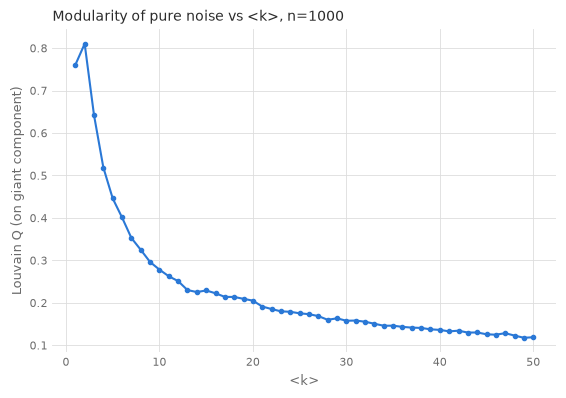

highest Q reached: 0.810 at <k>=2


In [57]:
kbars_noise = list(range(1, 51))
n_noise = 1000
q_vs_k = []
for i in tracked("Q vs <k> (n=1000)", len(kbars_noise)):
    kbar = kbars_noise[i]
    p = kbar / (n_noise - 1)
    g = nx.gnp_random_graph(n_noise, p, seed=SEED + i)
    giant = g.subgraph(max(nx.connected_components(g), key=len)).copy()   # take the giant component
    _, q1 = igraph_louvain(giant, seed=SEED)
    q_vs_k.append(q1)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(kbars_noise, q_vs_k, "-o", color=BLUE, markersize=3)
style(ax, "<k>", "Louvain Q (on giant component)")
ax.set_title("Modularity of pure noise vs <k>, n=1000", fontsize=10, color=INK, loc="left")
plt.show()
print(f"highest Q reached: {max(q_vs_k):.3f} at <k>={kbars_noise[np.argmax(q_vs_k)]}")

Q vs n (<k>=3): 1/5 (20%), 0s elapsed, about 0s left


Q vs n (<k>=3): 2/5 (40%), 0s elapsed, about 0s left


Q vs n (<k>=3): 3/5 (60%), 0s elapsed, about 0s left


Q vs n (<k>=3): 4/5 (80%), 0s elapsed, about 0s left


Q vs n (<k>=3): 5/5 (100%), 2s elapsed, about 0s left


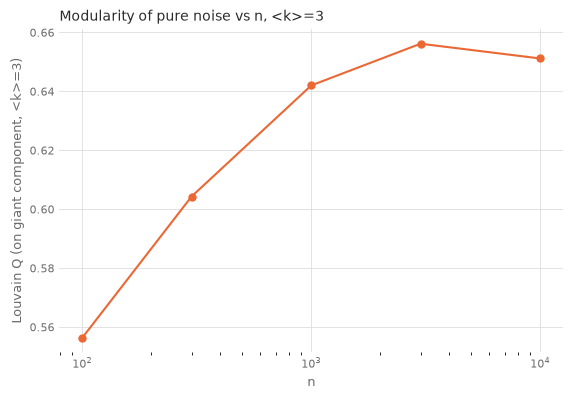

n=   100: Q = 0.556
n=   300: Q = 0.604
n=  1000: Q = 0.642
n=  3000: Q = 0.656
n= 10000: Q = 0.651


In [58]:
ns_noise = [100, 300, 1000, 3000, 10000]
q_vs_n = []
for i in tracked("Q vs n (<k>=3)", len(ns_noise)):
    n_i = ns_noise[i]
    p = 3 / (n_i - 1)
    g = nx.gnp_random_graph(n_i, p, seed=SEED + i)
    giant = g.subgraph(max(nx.connected_components(g), key=len)).copy()
    _, q1 = igraph_louvain(giant, seed=SEED)
    q_vs_n.append(q1)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(ns_noise, q_vs_n, "-o", color=ORANGE, markersize=5)
ax.set_xscale("log")
style(ax, "n", "Louvain Q (on giant component, <k>=3)")
ax.set_title("Modularity of pure noise vs n, <k>=3", fontsize=10, color=INK, loc="left")
plt.show()
for n_i, q_i in zip(ns_noise, q_vs_n):
    print(f"n={n_i:>6}: Q = {q_i:.3f}")

$Q$ falls steadily as $\langle k\rangle$ rises: a sparser network gives an optimizer more freedom to
draw cheap borders. Sweeping $n$ at fixed $\langle k\rangle=3$ moves $Q$ too, from 0.556 at n=100 up
to about 0.65 by n=3,000, then it levels off (printed above); size sets the score here, it does not
leave it flat. Both sweeps take the giant component before running Louvain, so isolates and small
fragments (free "communities" by construction) never inflate the score.

In [59]:
# two seeds per network in the <k> sweep, for NMI
nmi_noise = []
for i in tracked("NMI of two seeds, noise sweep", len(kbars_noise)):
    kbar = kbars_noise[i]
    p = kbar / (n_noise - 1)
    g = nx.gnp_random_graph(n_noise, p, seed=SEED + i)
    giant = g.subgraph(max(nx.connected_components(g), key=len)).copy()
    parts_a, _ = igraph_louvain(giant, seed=SEED)
    parts_b, _ = igraph_louvain(giant, seed=SEED + 999)
    lab_a = {n: c for c, comm in enumerate(parts_a) for n in comm}
    lab_b = {n: c for c, comm in enumerate(parts_b) for n in comm}
    common = list(giant.nodes())
    nmi_noise.append(nmi([lab_a[n] for n in common], [lab_b[n] for n in common]))

closest_idx = int(np.argmin(np.abs(np.array(q_vs_k) - Q_louvain)))
print(f"random network whose Q ({q_vs_k[closest_idx]:.3f}) is closest to Marvel's ({Q_louvain:.3f}): "
      f"<k>={kbars_noise[closest_idx]}")
print(f"its two-seed NMI: {nmi_noise[closest_idx]:.3f}   vs Marvel's 5-seed NMI range "
      f"[{off_diag.min():.3f}, {off_diag.max():.3f}]")

NMI of two seeds, noise sweep: 5/50 (10%), 0s elapsed, about 1s left


NMI of two seeds, noise sweep: 10/50 (20%), 0s elapsed, about 1s left


NMI of two seeds, noise sweep: 15/50 (30%), 0s elapsed, about 1s left


NMI of two seeds, noise sweep: 20/50 (40%), 1s elapsed, about 1s left


NMI of two seeds, noise sweep: 25/50 (50%), 1s elapsed, about 1s left


...

NMI of two seeds, noise sweep: 35/50 (70%), 2s elapsed, about 0s left


NMI of two seeds, noise sweep: 40/50 (80%), 2s elapsed, about 0s left


NMI of two seeds, noise sweep: 45/50 (90%), 3s elapsed, about 0s left


NMI of two seeds, noise sweep: 50/50 (100%), 3s elapsed, about 0s left


random network whose Q (0.401) is closest to Marvel's (0.387): <k>=6
its two-seed NMI: 0.186   vs Marvel's 5-seed NMI range [0.635, 0.904]


Modularity alone cannot tell the matched random network from Marvel; the stability check can. Marvel's
partitions agree across seeds far more than this random network's two seeds do at the same $Q$, showing
that a matching score is not evidence of matching structure: the NMI is the check that separates "a
score in the community-structure range" from "communities that are actually there."

In [60]:
karate_real = {n: karate.nodes[n]["club"] for n in karate.nodes()}
real_labels = [karate_real[n] for n in karate.nodes()]

Q_karate_weighted = nc.modularity(karate, [
    {n for n in karate.nodes() if karate_real[n] == club} for club in set(real_labels)
])
Q_karate_unweighted = nc.modularity(karate, [
    {n for n in karate.nodes() if karate_real[n] == club} for club in set(real_labels)
], weight=None)
print(f"karate real split: Q weighted = {Q_karate_weighted:.3f}   Q unweighted (weight=None) = {Q_karate_unweighted:.3f}")
print("the weighted score counts Zachary's interaction-frequency weights; the unweighted score counts links only")

karate_unweighted = nx.Graph()
karate_unweighted.add_nodes_from(karate.nodes())
karate_unweighted.add_edges_from(karate.edges())   # weight=None: strip Zachary's weights
karate_louvain_parts, Q_karate_louvain = igraph_louvain(karate_unweighted, seed=SEED)
karate_louvain_labels = {n: c for c, comm in enumerate(karate_louvain_parts) for n in comm}
nmi_karate = nmi([karate_louvain_labels[n] for n in karate.nodes()], real_labels)
print(f"Louvain (weight=None): {len(karate_louvain_parts)} communities, Q = {Q_karate_louvain:.3f}")
print(f"NMI(Louvain weight=None, real split) = {nmi_karate:.3f}")

karate real split: Q weighted = 0.391   Q unweighted (weight=None) = 0.358
the weighted score counts Zachary's interaction-frequency weights; the unweighted score counts links only
Louvain (weight=None): 4 communities, Q = 0.420
NMI(Louvain weight=None, real split) = 0.588


The weighted and unweighted karate scores differ because Zachary's edge weights concentrate inside the two real factions almost by definition (people interact more inside their own faction), giving the weighted score a higher ceiling that answers a slightly different question than the pure-topology unweighted score.

## 4.9: Infomap on Marvel

The `infomap` pip package is not installed; per the environment note we use igraph's
`community_infomap` instead, on the undirected giant, and compare with Louvain by NMI.

In [61]:
nodes_ig, h_ig, weights_ig = to_igraph(Ug)
ig.set_random_number_generator(random.Random(SEED))
infomap_part = h_ig.community_infomap(edge_weights=weights_ig)
infomap_parts = [{nodes_ig[i] for i in c} for c in infomap_part]
infomap_labels = {n: c for c, comm in enumerate(infomap_parts) for n in comm}

nmi_infomap_louvain = nmi([infomap_labels[n] for n in nodes_giant], runs[0][2])
print(f"Infomap: {len(infomap_parts)} modules")
print(f"Louvain (seed 0): {len(louvain_parts)} communities")
print(f"NMI(Infomap, Louvain) = {nmi_infomap_louvain:.3f}")

Infomap: 18 modules
Louvain (seed 0): 8 communities
NMI(Infomap, Louvain) = 0.666


In [62]:
# which groups agree, which one method splits that the other keeps together
louvain_labels_0 = runs[0][2]
cross = pd.crosstab(pd.Series([louvain_labels_0[i] for i in range(len(nodes_giant))], name="Louvain"),
                     pd.Series([infomap_labels[nodes_giant[i]] for i in range(len(nodes_giant))], name="Infomap"))
print("largest Louvain community's split across Infomap modules:")
biggest_louvain = cross.sum(axis=1).idxmax()
print(cross.loc[biggest_louvain].sort_values(ascending=False).head(5))

largest Louvain community's split across Infomap modules:
Infomap
9     16
8     16
14     6
2      4
13     2
Name: 6, dtype: int64


Where one Louvain community maps almost entirely onto one Infomap module, the two methods agree on that
group; where a single Louvain community's members scatter across several Infomap modules (the table
above), Infomap has split apart something Louvain's modularity optimization kept together, typically
because Infomap's map-equation objective rewards compressing a random walker's path rather than
maximizing the same links-inside-vs-expected quantity Louvain does.

**Validation against Wikipedia, skipped.** Reading the disagreeing characters' Wikipedia pages to judge
whether the split or the agreement corresponds to something real about the character requires a live
fetch this notebook does not do; it stays offline like the rest of the exercises above.

## 4.11: The backbone, skipped

Marvel is unweighted: every arc is one Wikipedia link, so there is no per-node weight
distribution for a disparity filter to compare each link against. The closest thing to a weight here,
reciprocity (a pair links once in one direction or once in both), carries no information a backbone
filter can use; there is nothing between "link exists" and "link does not." 4.11 runs on real,
information-carrying weights in `04_migration_exercises.ipynb` and `05_h1b_exercises.ipynb`, where
links are weighted by flow counts or filing counts.

## What we found

In [63]:
elapsed = time.time() - t0
print(f"notebook runtime so far: {span(elapsed)}")

notebook runtime so far: 2m15s


- **1.6**: n=303, m=1,434 undirected edges, $\langle k\rangle=9.5$ confirmed; Spider-Man leads
  in-degree at 106 and Betsy Braddock leads out-degree at 28, matching the explorable.
- **2.2-2.6**: random-network and Watts-Strogatz behavior reproduce the classic figures (Poisson at
  low $\langle k\rangle$, normal at high, a phase transition knee at $\langle k\rangle=1$, distance
  collapse by $q\approx0.05$-$0.1$ with clustering barely moved); the hand-written preferential
  attachment growth validated at a log-log slope near $-3$ against `barabasi_albert_graph`, and the
  Marvel in-degree's CCDF tracks a Barabasi-Albert network far more than a random one, though 303 nodes is
  too little data to settle "power law" against "lognormal" on its own.
- **2.8-2.9**: Marvel's clustering (0.32) survives both a configuration-model null (~0.11) and
  degree-preserving swaps (~0.15) by several standard deviations, with the gap between the two nulls
  traced to the hub links the configuration model deletes as duplicates; the friendship paradox holds
  at roughly the numbers the brief reports and survives a degree-preserving shuffle intact, because it
  is a function of the degree sequence alone.
- **3.3-3.9**: the giant component's diameter (6) and largest SCC (229) match the brief. A hand-written
  BFS agrees with networkx on 20 random starts; Hercules and Black Widow's betweenness sits several
  standard deviations above a degree-preserving shuffle's, confirming they are brokers rather than hubs;
  Marvel's mild disassortativity ($r=-0.105$) sits about 1.6 standard deviations from what its own
  degree sequence forces.
- **Cliques**: 1,835 triangles, 477 five-cliques, and a clique number of 8, with the brief's eight named
  X-Men one of six maximal 8-cliques that share a common six-member core. All asserted against the brief's numbers.
- **4.5-4.9**: Louvain on the Marvel giant component finds communities at a modularity level well
  above degree-preserving and $G(n,m)$ nulls; a hand-written Louvain phase 1 matches
  `nx.community.modularity` on the karate club; two random networks can share Marvel's
  modularity score while disagreeing on the actual partition far more across seeds, the gap a pure
  score cannot see but an NMI stability check can; Infomap and Louvain agree on most of the giant
  component and disagree on a few communities the map equation splits that modularity keeps whole.
- **Skipped**: the homophily sub-item of 3.9, the Wikipedia-reading validation in 4.9, and all of
  4.11, each for the reason given in its own section: no clean offline category label, no live
  Wikipedia access, and no per-link weight to filter on, respectively.